# Всплески бета/гамма как носители сигнала воображения и гармоническая бета



In [1]:
import numpy as np
from scipy.ndimage import label, find_objects
import pandas as pd 
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import json
import mne
import numpy as np
from tqdm import tqdm
import re
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from multiprocessing import Pool
import warnings

warnings.filterwarnings("ignore")

os.chdir('../../..')

## Что такое всплеск и как его посчитать?

Это отрезок времени, когда **мгновенная спектральная мощность** в выбранной частоте **выше порога**:

- порог = *среднее по триалу* + *2 стандартных отклонения* (для **этой частоты**);
- длительность события — **минимум 3 цикла**.  
Источник: https://www.nature.com/articles/s41467-023-36555-4

Формально (для мощности \(P(f,t)\)):

$$P(f,t) > \mu_{\text{trial}}(f) + 2\cdot\sigma_{\text{trial}}(f)$$

и условие по длительности (3 цикла):

$$\text{dur} \ge \frac{3}{f}$$

---


Делаем то же самое:

1) Берём мощность и переводим в лог-шкалу (чтобы значения были стабильнее):

$$L(f,t)=\log_{10}\left(P(f,t)+\varepsilon\right)$$

2) Выбираем baseline по времени (маска `baseline_mask`) и считаем **для каждой частоты отдельно** среднее и std:

$$\mu_{bl}(f)=\frac{1}{|T_{bl}|}\sum_{t\in T_{bl}} L(f,t)$$

$$\sigma_{bl}(f)=\sqrt{\frac{1}{|T_{bl}|-1}\sum_{t\in T_{bl}}\left(L(f,t)-\mu_{bl}(f)\right)^2}$$

3) Строим z-карту (насколько точка выше baseline):

$$Z(f,t)=\frac{L(f,t)-\mu_{bl}(f)}{\sigma_{bl}(f)+\delta}$$

4) Отмечаем точки выше порога:

$$Z(f,t) > z_{\text{thresh}}$$

(то же самое в log-power):

$$L(f,t) > \mu_{bl}(f) + z_{\text{thresh}}\cdot\sigma_{bl}(f)$$

5) Ищем **связные пятна** (clusters) в 2D маске *(частота × время)*.  
Каждое пятно = кандидат на burst.

6) Фильтруем по длительности:

$$\text{dur} = (t_{\text{end}}-t_{\text{start}})\cdot\Delta t$$

$$\text{оставляем, если } \text{dur} \ge \text{min\_dur}$$


p.s есть проблема, что 3 цикла я пока нигде не учитывала


In [113]:
def detect_power_patterns_per_channel(
        psd_all_channels,
        freqs,
        times,
        z_thresh=2.0,
        min_dur=0.1,
        freq_range=None,
        baseline_mask=None
    ):
    """
    psd_all_channels : (n_channels, n_freqs, n_times) или (n_freqs, n_times)
    """

    psd = psd_all_channels

    n_ch, n_f, n_t = psd.shape

    # Ограничение по частотам
    if freq_range is not None:
        f_low, f_high = freq_range
        freq_mask = (freqs >= f_low) & (freqs <= f_high)
        freqs_sel = freqs[freq_mask]
        psd_sel = psd[:, freq_mask, :]
    else:
        freqs_sel = freqs
        psd_sel = psd

    # Базлайн маска
    if baseline_mask is None:
        baseline_mask = np.ones_like(times, dtype=bool)
    else:
        baseline_mask = np.asarray(baseline_mask, dtype=bool)

    patterns = []

    for ch_idx in range(n_ch):
        psd_ch = psd_sel[ch_idx]          # (n_f_sel, n_t)
        log_power = np.log10(psd_ch + 1e-10)

        # БАЗЛАЙН ОТДЕЛЬНО ДЛЯ КАЖДОЙ ЧАСТОТЫ
        if np.any(baseline_mask):
            baseline_tf = log_power[:, baseline_mask]   # (n_f_sel, n_bl_t)
        else:
            baseline_tf = log_power                      # (n_f_sel, n_t)

        mean_bl = baseline_tf.mean(axis=1, keepdims=True)  # (n_f_sel, 1)

        if baseline_tf.shape[1] > 1:
            std_bl = baseline_tf.std(axis=1, ddof=1, keepdims=True)  # (n_f_sel, 1)
        else:
            std_bl = np.ones((baseline_tf.shape[0], 1), dtype=baseline_tf.dtype)

        std_bl = np.where(std_bl < 1e-12, 1.0, std_bl)

        z_map = (log_power - mean_bl) / (std_bl + 1e-10)
        mask = z_map > z_thresh

        labeled, num = label(mask)
        objects = find_objects(labeled)

        for sl in objects:
            f_slice, t_slice = sl
            f_start, f_end = f_slice.start, f_slice.stop
            t_start, t_end = t_slice.start, t_slice.stop

            dur = (t_end - t_start) * (times[1] - times[0])
            if dur < min_dur:
                continue

            patterns.append({
                'ch': ch_idx,
                'freq_low': freqs_sel[f_start],
                'freq_high': freqs_sel[f_end - 1],
                'time_start': times[t_start],
                'time_end': times[t_end - 1],
            })

    return patterns


In [3]:
def safe_get(loaded, key, as_int=False, as_str=False):
    """
    Аккуратно достаёт скаляр из npz.
    - Если ключа нет -> None
    - Если это np.ndarray со shape=() или 1 элементом -> .item()
    - Если внутри None -> None
    - Если as_int/as_str=True, пытается привести к нужному типу.
    """
    if key not in loaded:
        return None

    val = loaded[key]

    # Разворачиваем np.array со скаляром или одним элементом
    if isinstance(val, np.ndarray):
        if val.shape == ():          # например, array(2, dtype=int64)
            val = val.item()
        elif val.size == 1:
            val = val.reshape(-1)[0]

    # Если это явно None — дальше не трогаем
    if val is None:
        return None

    if as_int:
        try:
            return int(val)
        except Exception:
            return None

    if as_str:
        try:
            return str(val)
        except Exception:
            return None

    return val


Загружаем данные. Использовала `exec_and_rest_morlets.npz` из-за того, что есть img и command parts 

In [4]:
loaded = np.load('./Generated/Spectrums/exec_and_rest_morlets.npz', allow_pickle=True)

results_arr = []

i = 0
while f'power_{i}' in loaded:

    power = loaded[f'power_{i}']
    phase = loaded[f'phase_{i}'] if f'phase_{i}' in loaded else None

    s_id      = safe_get(loaded, f'subject_id_{i}', as_int=True)
    t_id      = safe_get(loaded, f'trial_id_{i}',   as_int=True)
    gender    = safe_get(loaded, f'gender_{i}',     as_str=True)
    handiness = safe_get(loaded, f'handiness_{i}',  as_str=True)
    age       = safe_get(loaded, f'age_{i}',        as_int=True)
    label_val = safe_get(loaded, f'label_{i}',      as_int=True)
    task_type = safe_get(loaded, f'task_type_{i}',  as_str=True)

    img = loaded[f'img_{i}'] if f'img_{i}' in loaded else None

    results_arr.append([
        power,
        phase,
        s_id,
        t_id,
        gender,
        handiness,
        age,
        label_val,
        img,
        task_type
    ])
    i += 1

print("Триалов загружено:", len(results_arr))

power, phase, s_id, t_id, gender, handiness, age, label_val, img, task_type = results_arr[0]
print("power.shape:", power.shape)
print("label_val_0:", label_val, type(label_val))



Триалов загружено: 1260
power.shape: (63, 195, 411)
label_val_0: 2 <class 'int'>


In [5]:
from multiprocessing import Pool

def process_trial(args):
    """
    Обработка одного триала для multiprocessing.Pool.
    args = (trial_idx, trial)
    Возвращает (beta_patterns, gamma_patterns) для этого триала.
    """
    trial_idx, trial = args
    power, phase, s_id, t_id, gender, handiness, age, label_val, img, task_type = trial
    
    n_ch, n_freqs, n_times = power.shape

    freqs = np.linspace(2, 40, n_freqs)  

    # Время: шаг 50 мс 
    dt = 50 / 1000.0
    times = np.arange(n_times) * dt

    if np.any(times < 0):
        baseline_mask = times < 0
    else:
        baseline_mask = None

    # БЕТА
    beta_patterns = detect_power_patterns_per_channel(
        power,
        freqs,
        times,
        z_thresh=2.0,
        min_dur=0.2,
        freq_range=(13, 30),
        baseline_mask=baseline_mask
    )

    # ГАММА
    gamma_patterns = detect_power_patterns_per_channel(
        power,
        freqs,
        times,
        z_thresh=2.0,
        min_dur=0.2,
        freq_range=(30, 40),   # если частоты до 40 Гц
        baseline_mask=baseline_mask
    )


    for p in beta_patterns:
        p['trial'] = trial_idx
        p['task_type'] = task_type
        p['label_val'] = label_val

    for p in gamma_patterns:
        p['trial'] = trial_idx
        p['task_type'] = task_type
        p['label_val'] = label_val

    return beta_patterns, gamma_patterns


In [6]:
N_PROCESSES = 45

args_list = list(enumerate(results_arr)) 

all_beta = []
all_gamma = []

def collect_result(result):
    """callback для apply_async: здесь собираем результат и двигаем прогресс"""
    beta_patterns, gamma_patterns = result
    all_beta.extend(beta_patterns)
    all_gamma.extend(gamma_patterns)
    collect_result.pbar.update(1)   # +1 обработанный триал

with Pool(processes=N_PROCESSES) as pool:
    with tqdm(total=len(args_list)) as pbar:
        collect_result.pbar = pbar  # передаём pbar в callback через атрибут

        for args in args_list:
            pool.apply_async(process_trial, (args,), callback=collect_result)

        pool.close()
        pool.join()

print("Всего бета-всплесков:", len(all_beta))
print("Всего гамма-всплесков:", len(all_gamma))


100%|██████████| 1260/1260 [02:54<00:00,  7.20it/s]

Всего бета-всплесков: 173192
Всего гамма-всплесков: 24041


In [7]:
df_beta = pd.DataFrame(all_beta)
df_gamma = pd.DataFrame(all_gamma)

for df in (df_beta, df_gamma):
    df['duration'] = df['time_end'] - df['time_start']

print("df_beta:", df_beta.shape)
print(df_beta.head())

print("df_gamma:", df_gamma.shape)
print(df_gamma.head())

print("Уникальные task_type (beta):", df_beta['task_type'].unique())
print("Уникальные task_type (gamma):", df_gamma['task_type'].unique())



df_beta: (173192, 9)
   ch   freq_low  freq_high  time_start  time_end  trial task_type  label_val  \
0   0  23.154639  28.639175        2.45      2.60      0         g          2   
1   6  13.164948  15.319588        1.55      1.70      0         g          2   
2   7  13.164948  14.340206        4.95      5.15      0         g          2   
3   7  13.164948  14.731959       19.85     20.00      0         g          2   
4  21  13.164948  13.752577        5.15      5.35      0         g          2   

   duration  
0      0.15  
1      0.15  
2      0.20  
3      0.15  
4      0.20  
df_gamma: (24041, 9)
   ch   freq_low  freq_high  time_start  time_end  trial task_type  label_val  \
0   2  33.144330  40.000000        0.25      0.50      0         g          2   
1   3  34.907216  39.020619        1.70      1.85      0         g          2   
2   6  34.515464  39.216495        0.25      0.45      0         g          2   
3   7  31.969072  38.824742        0.35      0.55      0       

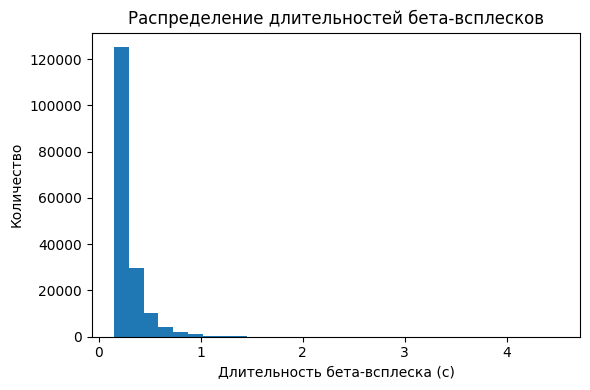

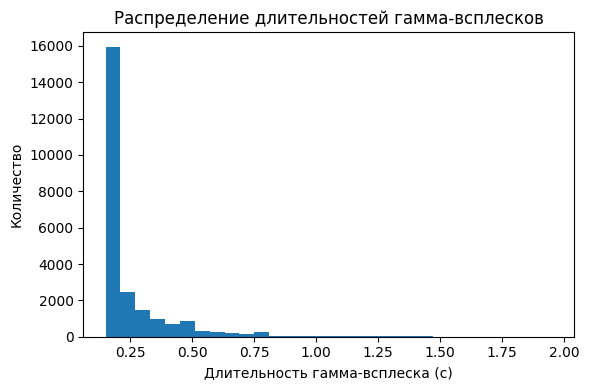

In [8]:
plt.figure(figsize=(6,4))
plt.hist(df_beta['duration'], bins=30)
plt.xlabel('Длительность бета-всплеска (с)')
plt.ylabel('Количество')
plt.title('Распределение длительностей бета-всплесков')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_gamma['duration'], bins=30)
plt.xlabel('Длительность гамма-всплеска (с)')
plt.ylabel('Количество')
plt.title('Распределение длительностей гамма-всплесков')
plt.tight_layout()
plt.show()


In [9]:
beta_counts = (
    df_beta
    .groupby(['task_type', 'label_val'])['trial']
    .count()
    .reset_index(name='n_beta_bursts')
)

gamma_counts = (
    df_gamma
    .groupby(['task_type', 'label_val'])['trial']
    .count()
    .reset_index(name='n_gamma_bursts')
)

print("beta_counts shape:", beta_counts.shape)
print(beta_counts.head())

print("gamma_counts shape:", gamma_counts.shape)
print(gamma_counts.head())


beta_counts shape: (14, 3)
  task_type  label_val  n_beta_bursts
0         g          0           6016
1         g          1           8867
2         g          2           8095
3         g          3           9657
4         g          4          11185
gamma_counts shape: (14, 3)
  task_type  label_val  n_gamma_bursts
0         g          0             830
1         g          1            1238
2         g          2            1089
3         g          3             972
4         g          4            1198


In [10]:
print("каналов с бета-всплесками:", df_beta['ch'].nunique())
print("список каналов (beta):", sorted(df_beta['ch'].unique()))

print("каналов с гамма-всплесками:", df_gamma['ch'].nunique())
print("список каналов (gamma):", sorted(df_gamma['ch'].unique()))


каналов с бета-всплесками: 63
список каналов (beta): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]
каналов с гамма-всплесками: 63
список каналов (gamma): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]


<Figure size 800x400 with 0 Axes>

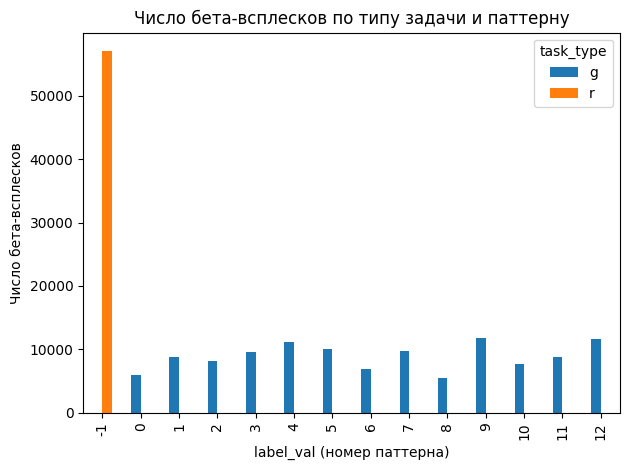

In [11]:
beta_pivot = beta_counts.pivot(index='label_val', columns='task_type', values='n_beta_bursts')

plt.figure(figsize=(8, 4))
beta_pivot.plot(kind='bar')
plt.xlabel('label_val (номер паттерна)')
plt.ylabel('Число бета-всплесков')
plt.title('Число бета-всплесков по типу задачи и паттерну')
plt.tight_layout()
plt.show()


<Figure size 800x400 with 0 Axes>

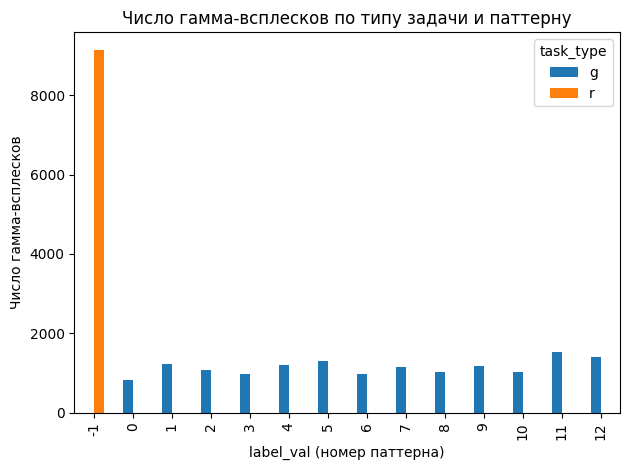

In [12]:
gamma_pivot = gamma_counts.pivot(index='label_val', columns='task_type', values='n_gamma_bursts')

plt.figure(figsize=(8, 4))
gamma_pivot.plot(kind='bar')
plt.xlabel('label_val (номер паттерна)')
plt.ylabel('Число гамма-всплесков')
plt.title('Число гамма-всплесков по типу задачи и паттерну')
plt.tight_layout()
plt.show()


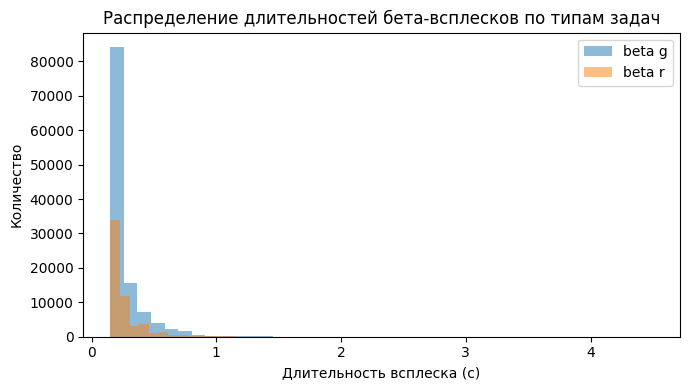

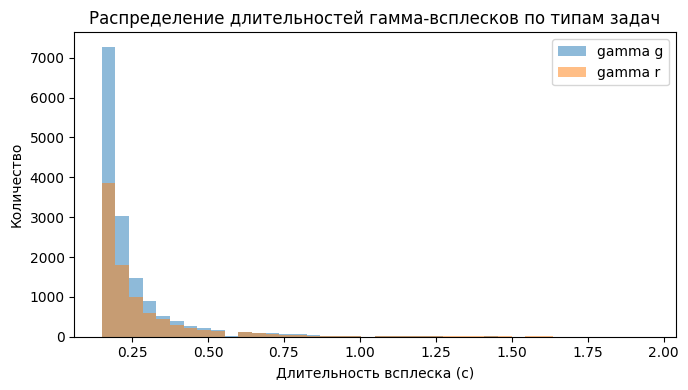

In [13]:
plt.figure(figsize=(7, 4))
for tp in df_beta['task_type'].unique():
    subset = df_beta[df_beta['task_type'] == tp]
    plt.hist(subset['duration'], bins=40, alpha=0.5, label=f'beta {tp}')

plt.xlabel('Длительность всплеска (с)')
plt.ylabel('Количество')
plt.title('Распределение длительностей бета-всплесков по типам задач')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
for tp in df_gamma['task_type'].unique():
    subset = df_gamma[df_gamma['task_type'] == tp]
    plt.hist(subset['duration'], bins=40, alpha=0.5, label=f'gamma {tp}')

plt.xlabel('Длительность всплеска (с)')
plt.ylabel('Количество')
plt.title('Распределение длительностей гамма-всплесков по типам задач')
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
beta_trial = (
    df_beta
    .groupby(['trial', 'task_type'])
    .agg(
        n_beta=('duration', 'size'),
        beta_duration_sum=('duration', 'sum')
    )
    .reset_index()
)

gamma_trial = (
    df_gamma
    .groupby(['trial', 'task_type'])
    .agg(
        n_gamma=('duration', 'size'),
        gamma_duration_sum=('duration', 'sum')
    )
    .reset_index()
)

trial_features = (
    beta_trial
    .merge(gamma_trial, on=['trial', 'task_type'], how='outer')
    .fillna(0)
)

print(trial_features.head())
print(trial_features.columns)


   trial task_type  n_beta  beta_duration_sum  n_gamma  gamma_duration_sum
0      0         g      24               4.70     15.0                3.55
1      1         g      10               1.75      3.0                0.60
2      2         g      19               3.50      3.0                0.55
3      3         g      15               2.65      5.0                0.80
4      4         g      20               3.20      6.0                1.00
Index(['trial', 'task_type', 'n_beta', 'beta_duration_sum', 'n_gamma',
       'gamma_duration_sum'],
      dtype='object')


In [15]:

from scipy import stats

features = ['n_beta', 'beta_duration_sum', 'n_gamma', 'gamma_duration_sum']

for feat in features:
    g_vals = trial_features.loc[trial_features['task_type'] == 'g', feat]
    r_vals = trial_features.loc[trial_features['task_type'] == 'r', feat]

    m_g, m_r = g_vals.mean(), r_vals.mean()
    s_g, s_r = g_vals.std(ddof=1), r_vals.std(ddof=1)

    n_g, n_r = len(g_vals), len(r_vals)
    s_pooled = np.sqrt(((n_g-1)*s_g**2 + (n_r-1)*s_r**2) / (n_g+n_r-2))
    d = (m_g - m_r) / s_pooled

    U, p = stats.mannwhitneyu(g_vals, r_vals, alternative='two-sided')

    print(f"\n {feat}")
    print(f"mean(g)={m_g:.2f}, mean(r)={m_r:.2f}, d={d:.2f}, p={p:.3e}")



 n_beta
mean(g)=138.20, mean(r)=135.96, d=0.02, p=8.788e-01

 beta_duration_sum
mean(g)=35.14, mean(r)=35.20, d=-0.00, p=9.665e-01

 n_gamma
mean(g)=17.76, mean(r)=21.72, d=-0.16, p=8.988e-01

 gamma_duration_sum
mean(g)=4.20, mean(r)=5.78, d=-0.17, p=9.145e-01


In [16]:
def add_time_window(df, edges, labels):
    """
    edges: границы по времени (секунды), напр. [0.0, 0.5, 5.5, 20.5]
    labels: названия окон, напр. ['command', 'imagine', 'rest2']
    """
    df = df.copy()
    t_mid = (df['time_start'] + df['time_end']) / 2.0
    df['win'] = pd.cut(
        t_mid,
        bins=edges,
        labels=labels,
        include_lowest=True,
        right=False   # полуинтервалы [a, b)
    )
    return df

edges  = [0.0, 0.5, 10.5, 20.5]
labels = ['command', 'imagine', 'rest2']

df_beta_w  = add_time_window(df_beta,  edges, labels)
df_gamma_w = add_time_window(df_gamma, edges, labels)

print(df_beta_w[['time_start','time_end','win']].head())


   time_start  time_end      win
0        2.45      2.60  imagine
1        1.55      1.70  imagine
2        4.95      5.15  imagine
3       19.85     20.00    rest2
4        5.15      5.35  imagine


In [17]:
beta_tw = (
    df_beta_w
    .groupby(['trial', 'task_type', 'win'])['duration']
    .agg(
        n_beta='size',
        beta_dur_sum='sum'
    )
    .reset_index()
)

# разворачиваем окна в столбцы
beta_tw_pivot = beta_tw.pivot(
    index=['trial', 'task_type'],
    columns='win',
    values='n_beta'   # можно заменить на 'beta_dur_sum' для суммарной длительности
).reset_index()

beta_tw_pivot = beta_tw_pivot.rename(columns={
    'command': 'n_beta_cmd',
    'imagine': 'n_beta_img',
    'rest2':   'n_beta_rest2'
})

print(beta_tw_pivot.head())


win  trial task_type  n_beta_cmd  n_beta_img  n_beta_rest2
0        0         g           8          13             3
1        0         r           0           0             0
2        1         g           0           6             4
3        1         r           0           0             0
4        2         g           1           3            15


In [18]:
gamma_tw = (
    df_gamma_w
    .groupby(['trial', 'task_type', 'win'])['duration']
    .agg(
        n_gamma='size',
        gamma_dur_sum='sum'
    )
    .reset_index()
)

gamma_tw_pivot = gamma_tw.pivot(
    index=['trial', 'task_type'],
    columns='win',
    values='n_gamma'
).reset_index()

gamma_tw_pivot = gamma_tw_pivot.rename(columns={
    'command': 'n_gamma_cmd',
    'imagine': 'n_gamma_img',
    'rest2':   'n_gamma_rest2'
})

print(gamma_tw_pivot.head())


win  trial task_type  n_gamma_cmd  n_gamma_img  n_gamma_rest2
0        0         g           11            4              0
1        0         r            0            0              0
2        1         g            0            1              2
3        1         r            0            0              0
4        2         g            1            1              1


In [19]:
trial_features_base = trial_features[['trial','task_type','n_beta','beta_duration_sum',
                                      'n_gamma','gamma_duration_sum']].copy()

print(beta_tw_pivot.columns)
print(gamma_tw_pivot.columns)

beta_cols  = ['trial', 'task_type', 'n_beta_cmd', 'n_beta_img', 'n_beta_rest2']
gamma_cols = ['trial', 'task_type', 'n_gamma_cmd', 'n_gamma_img', 'n_gamma_rest2']

trial_features = (
    trial_features_base
    .merge(beta_tw_pivot[beta_cols],  on=['trial','task_type'], how='left')
    .merge(gamma_tw_pivot[gamma_cols], on=['trial','task_type'], how='left')
    .fillna(0)
)

print(trial_features.columns)
print(trial_features.head())


Index(['trial', 'task_type', 'n_beta_cmd', 'n_beta_img', 'n_beta_rest2'], dtype='object', name='win')
Index(['trial', 'task_type', 'n_gamma_cmd', 'n_gamma_img', 'n_gamma_rest2'], dtype='object', name='win')
Index(['trial', 'task_type', 'n_beta', 'beta_duration_sum', 'n_gamma',
       'gamma_duration_sum', 'n_beta_cmd', 'n_beta_img', 'n_beta_rest2',
       'n_gamma_cmd', 'n_gamma_img', 'n_gamma_rest2'],
      dtype='object')
   trial task_type  n_beta  beta_duration_sum  n_gamma  gamma_duration_sum  \
0      0         g      24               4.70     15.0                3.55   
1      1         g      10               1.75      3.0                0.60   
2      2         g      19               3.50      3.0                0.55   
3      3         g      15               2.65      5.0                0.80   
4      4         g      20               3.20      6.0                1.00   

   n_beta_cmd  n_beta_img  n_beta_rest2  n_gamma_cmd  n_gamma_img  \
0           8          13         

In [20]:
for feat in ['n_beta_img', 'n_gamma_img']:
    g_vals = trial_features.loc[trial_features['task_type']=='g', feat]
    r_vals = trial_features.loc[trial_features['task_type']=='r', feat]

    m_g, m_r = g_vals.mean(), r_vals.mean()
    U, p = stats.mannwhitneyu(g_vals, r_vals, alternative='two-sided')

    print(f"{feat}: mean(g)={m_g:.2f}, mean(r)={m_r:.2f}, p={p:.3e}")


n_beta_img: mean(g)=67.54, mean(r)=65.06, p=7.017e-01
n_gamma_img: mean(g)=8.67, mean(r)=11.41, p=9.876e-01


In [21]:
g_vals = trial_features.loc[trial_features['task_type']=='g', 'n_beta_img']
r_vals = trial_features.loc[trial_features['task_type']=='r', 'n_beta_img']

m_g, m_r = g_vals.mean(), r_vals.mean()
s_g, s_r = g_vals.std(ddof=1), r_vals.std(ddof=1)
n_g, n_r = len(g_vals), len(r_vals)

s_pooled = np.sqrt(((n_g-1)*s_g**2 + (n_r-1)*s_r**2) / (n_g+n_r-2))
d = (m_g - m_r) / s_pooled
print("Cohen's d for n_beta_img:", d)


Cohen's d for n_beta_img: 0.037897752141680195


In [22]:
df_beta_img = df_beta_w[df_beta_w['win'] == 'imagine']

# считаем, сколько всплесков на каждом канале для g и r
beta_ch_cond = (
    df_beta_img
    .groupby(['ch', 'task_type'])['duration']
    .size()
    .reset_index(name='n_beta_bursts')
)

# разворачиваем в таблицу ch × (g,r)
beta_ch_pivot = beta_ch_cond.pivot(
    index='ch',
    columns='task_type',
    values='n_beta_bursts'
).fillna(0)

# считаем разницу g - r
beta_ch_pivot['diff_g_minus_r'] = beta_ch_pivot.get('g', 0) - beta_ch_pivot.get('r', 0)

# сортируем по убыванию разницы
beta_ch_pivot_sorted = beta_ch_pivot.sort_values('diff_g_minus_r', ascending=False)

print(beta_ch_pivot_sorted.head(15))  # первые 15 каналов с наибольшей разницей


task_type     g    r  diff_g_minus_r
ch                                  
52         1557  695             862
49         1596  745             851
47         1444  639             805
19         1491  693             798
48         1505  725             780
21         1377  616             761
23         1383  633             750
18         1428  692             736
44         1265  560             705
46         1372  682             690
17         1219  570             649
7          1345  696             649
54         1101  460             641
45         1217  588             629
41         1198  573             625


In [23]:
TOP_N = 12 

roi_channels = beta_ch_pivot_sorted.head(TOP_N).index.to_list()
print("ROI channels (by index):", roi_channels)


ROI channels (by index): [52, 49, 47, 19, 48, 21, 23, 18, 44, 46, 17, 7]


In [24]:
df_beta['in_roi'] = df_beta['ch'].isin(roi_channels)

# только окно imagine
df_beta_img = df_beta_w[df_beta_w['win'] == 'imagine'].copy()
df_beta_img['in_roi'] = df_beta_img['ch'].isin(roi_channels)

beta_img_trial_roi = (
    df_beta_img
    .groupby(['trial','task_type'])
    .agg(
        n_beta_img_all=('duration','size'),
        n_beta_img_roi=('in_roi','sum')
    )
    .reset_index()
)

beta_img_trial_roi['beta_img_roi_ratio'] = (
    beta_img_trial_roi['n_beta_img_roi'] /
    beta_img_trial_roi['n_beta_img_all'].replace(0, np.nan)
)


In [25]:
for feat in ['n_beta_img_roi', 'beta_img_roi_ratio']:
    g_vals = beta_img_trial_roi.loc[beta_img_trial_roi['task_type']=='g', feat]
    r_vals = beta_img_trial_roi.loc[beta_img_trial_roi['task_type']=='r', feat]

    m_g, m_r = g_vals.mean(), r_vals.mean()
    U, p = stats.mannwhitneyu(g_vals, r_vals, alternative='two-sided')

    print(f"{feat}: mean(g)={m_g:.2f}, mean(r)={m_r:.2f}, p={p:.3e}")


n_beta_img_roi: mean(g)=20.24, mean(r)=18.92, p=3.260e-01
beta_img_roi_ratio: mean(g)=0.32, mean(r)=0.30, p=1.017e-01


In [26]:
def cohens_d(g, r):
    m_g, m_r = g.mean(), r.mean()
    s_g, s_r = g.std(ddof=1), r.std(ddof=1)
    n_g, n_r = len(g), len(r)
    s_pooled = np.sqrt(((n_g-1)*s_g**2 + (n_r-1)*s_r**2) / (n_g+n_r-2))
    return (m_g - m_r) / s_pooled

g1 = beta_img_trial_roi.loc[beta_img_trial_roi['task_type']=='g', 'n_beta_img_roi']
r1 = beta_img_trial_roi.loc[beta_img_trial_roi['task_type']=='r', 'n_beta_img_roi']
g2 = beta_img_trial_roi.loc[beta_img_trial_roi['task_type']=='g', 'beta_img_roi_ratio']
r2 = beta_img_trial_roi.loc[beta_img_trial_roi['task_type']=='r', 'beta_img_roi_ratio']

print("d(n_beta_img_roi)    =", cohens_d(g1, r1))
print("d(beta_img_roi_ratio)=", cohens_d(g2, r2))


d(n_beta_img_roi)    = 0.07413029162695217
d(beta_img_roi_ratio)= 0.1207725898725847


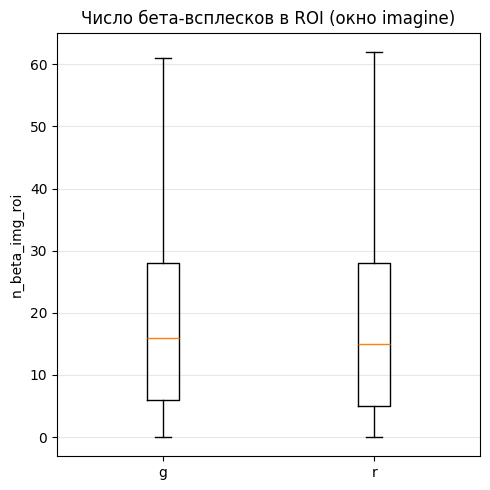

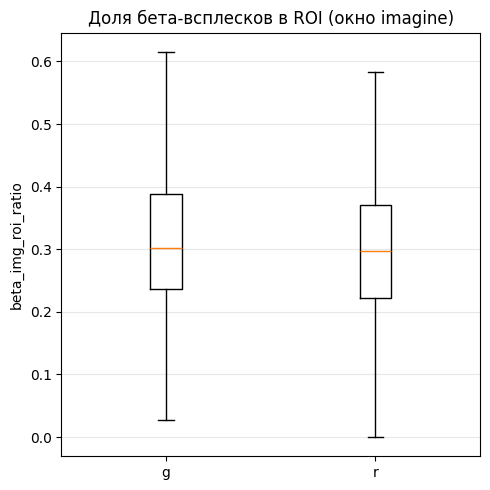

In [27]:
def boxplot_feature(df, feat, title=None):
    plt.figure(figsize=(5, 5))
    
    data = [
        df.loc[df['task_type']=='g', feat],
        df.loc[df['task_type']=='r', feat],
    ]
    labels = ['g', 'r']

    plt.boxplot(data, labels=labels, showfliers=False)
    plt.ylabel(feat)
    if title is None:
        title = feat
    plt.title(title)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

boxplot_feature(beta_img_trial_roi, 'n_beta_img_roi',
                title='Число бета-всплесков в ROI (окно imagine)')
boxplot_feature(beta_img_trial_roi, 'beta_img_roi_ratio',
                title='Доля бета-всплесков в ROI (окно imagine)')

In [28]:
# только окно imagine
df_beta_img = df_beta_w[df_beta_w['win'] == 'imagine']

beta_ch_cond = (
    df_beta_img
    .groupby(['ch', 'task_type'])['duration']
    .size()
    .reset_index(name='n_beta_bursts')
)

beta_ch_pivot = beta_ch_cond.pivot(
    index='ch',
    columns='task_type',
    values='n_beta_bursts'
).fillna(0)

# на всякий случай, если вдруг какого-то типа нет
beta_ch_pivot['g'] = beta_ch_pivot.get('g', 0)
beta_ch_pivot['r'] = beta_ch_pivot.get('r', 0)

beta_ch_pivot['diff_g_minus_r'] = beta_ch_pivot['g'] - beta_ch_pivot['r']

print(beta_ch_pivot.head())


task_type    g    r  diff_g_minus_r
ch                                 
0          436  253             183
1          694  351             343
2          539  257             282
3          697  333             364
4          736  314             422


In [29]:
path = './Generated/Data/S_1/Trial_1/EEG_clean.fif' 

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    raw = mne.io.read_raw_fif(path, preload=False, verbose=False)

eeg = raw.copy().pick_types(eeg=True)
eeg.set_montage('standard_1020', on_missing='warn', match_case=False)

info       = eeg.info
ch_names   = info['ch_names']
n_channels = len(ch_names)

print("Каналов в info:", n_channels)


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Каналов в info: 63


In [30]:
# оставляем только окно imagine
df_beta_img = df_beta_w[df_beta_w['win'] == 'imagine']

# считаем число бета-всплесков по каналам и task_type
beta_ch_cond = (
    df_beta_img
    .groupby(['ch', 'task_type'])['duration']
    .size()
    .reset_index(name='n_beta_bursts')
)

# pivot: ch × (g, r)
beta_ch_pivot = beta_ch_cond.pivot(
    index='ch',
    columns='task_type',
    values='n_beta_bursts'
).fillna(0)

# приводим к полному списку каналов 0..n_channels-1
beta_ch_full = beta_ch_pivot.reindex(index=np.arange(n_channels)).fillna(0)

# данные для карт
beta_g    = beta_ch_full.get('g', 0).values
beta_r    = beta_ch_full.get('r', 0).values
beta_diff = beta_g - beta_r


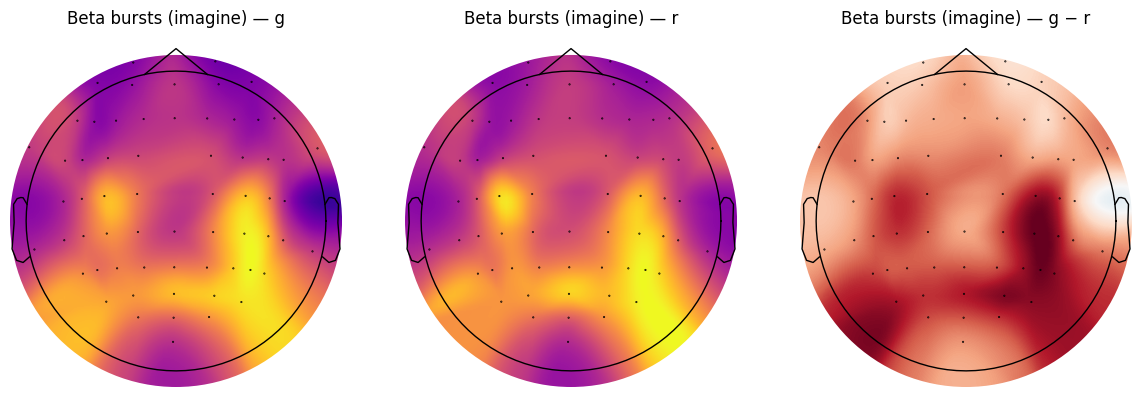

In [31]:
from mne.viz import plot_topomap

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# 1) Бета-всплески при g
plot_topomap(beta_g, info, axes=axs[0],
             show=False, cmap='plasma', contours=0)
axs[0].set_title('Beta bursts (imagine) — g')

# 2) Бета-всплески при r
plot_topomap(beta_r, info, axes=axs[1],
             show=False, cmap='plasma', contours=0)
axs[1].set_title('Beta bursts (imagine) — r')

# 3) Разность g − r, с симметричной шкалой
vmax = float(np.nanmax(np.abs(beta_diff))) if np.any(np.isfinite(beta_diff)) else 1.0
plot_topomap(beta_diff, info, axes=axs[2],
             show=False, cmap='RdBu_r', contours=0,
             vlim=(-vmax, vmax))
axs[2].set_title('Beta bursts (imagine) — g − r')

plt.tight_layout()
plt.show()


In [32]:

trial2sid = {i: results_arr[i][2] for i in range(len(results_arr))}

df_beta['s_id'] = df_beta['trial'].map(trial2sid)
df_beta_w['s_id'] = df_beta_w['trial'].map(trial2sid)

print(df_beta[['trial', 's_id', 'task_type']].head())


df_beta_img = df_beta_w[df_beta_w['win'] == 'imagine'].copy()
group_cols = ['s_id', 'task_type', 'trial', 'ch']

beta_trial_ch = (
    df_beta_img
    .groupby(group_cols)['duration']
    .size()
    .reset_index(name='n_beta_bursts')
)
# (s_id, task_type, trial) × ch
beta_trial_mat = beta_trial_ch.pivot_table(
    index=['s_id', 'task_type', 'trial'],
    columns='ch',
    values='n_beta_bursts',
    fill_value=0
)

print(beta_trial_mat.shape)
beta_trial_mat.head()


   trial  s_id task_type
0      0     5         g
1      0     5         g
2      0     5         g
3      0     5         g
4      0     5         g
(1259, 63)


ch                     0    1    2    3    4    5    6    7    8    9   ...  \
s_id task_type trial                                                    ...   
1    g         168    0.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  1.0  0.0  ...   
               169    0.0  1.0  1.0  2.0  2.0  1.0  0.0  1.0  2.0  0.0  ...   
               170    0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0  0.0  0.0  ...   
               171    2.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0  ...   
               172    1.0  1.0  1.0  0.0  1.0  1.0  1.0  1.0  2.0  0.0  ...   

ch                     53   54   55   56   57   58   59   60   61   62  
s_id task_type trial                                                    
1    g         168    0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  
               169    1.0  1.0  0.0  1.0  1.0  0.0  0.0  0.0  1.0  0.0  
               170    1.0  1.0  0.0  0.0  1.0  0.0  1.0  0.0  0.0  0.0  
               171    0.0  0.0  0.0  0.0  2.0  0.0  0.0  1.0  0.0  0.0  
               172    1.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  2.0  0.0  

[5 rows x 63 columns]

In [33]:
pattern_mat = beta_trial_mat.copy().astype(float)
row_sums = pattern_mat.sum(axis=1).replace(0, np.nan)
pattern_mat = pattern_mat.div(row_sums, axis=0)  # делим по строкам

print(pattern_mat.head())


ch                          0         1         2         3         4   \
s_id task_type trial                                                     
1    g         168    0.000000  0.000000  0.000000  0.000000  0.000000   
               169    0.000000  0.012048  0.012048  0.024096  0.024096   
               170    0.000000  0.000000  0.000000  0.000000  0.037037   
               171    0.125000  0.062500  0.000000  0.000000  0.062500   
               172    0.012346  0.012346  0.012346  0.000000  0.012346   

ch                          5         6         7         8    9   ...  \
s_id task_type trial                                               ...   
1    g         168    0.055556  0.000000  0.055556  0.055556  0.0  ...   
               169    0.012048  0.000000  0.012048  0.024096  0.0  ...   
               170    0.037037  0.037037  0.037037  0.000000  0.0  ...   
               171    0.000000  0.000000  0.000000  0.062500  0.0  ...   
               172    0.012346  0.012

In [34]:
templates = (
    pattern_mat
    .groupby(['s_id', 'task_type'])
    .mean()
)  # индекс: (s_id, task_type), колонки: ch

print(templates.head())


ch                    0         1         2         3         4         5   \
s_id task_type                                                               
1    g          0.010117  0.011253  0.004045  0.012104  0.013759  0.012210   
     r          0.014638  0.007458  0.009442  0.009470  0.007187  0.014500   
2    g          0.009236  0.010543  0.011768  0.014726  0.021338  0.012837   
     r          0.010659  0.010824  0.010968  0.029728  0.008648  0.019700   
3    g          0.029250  0.028198  0.015093  0.022356  0.009684  0.018604   

ch                    6         7         8         9   ...        53  \
s_id task_type                                          ...             
1    g          0.012187  0.018668  0.024994  0.011856  ...  0.014628   
     r          0.014507  0.017838  0.016157  0.019726  ...  0.020582   
2    g          0.013142  0.020208  0.016760  0.015131  ...  0.008965   
     r          0.011939  0.029852  0.025164  0.013385  ...  0.018520   
3    g         

In [35]:
from scipy.stats import pearsonr

rows = []
for (s_id, task_type, trial), row in pattern_mat.iterrows():
    v = row.values

    tmpl_same = templates.loc[(s_id, task_type)].values
    
    # другой тип (g ↔ r)
    other_type = 'g' if task_type == 'r' else 'r'
    if (s_id, other_type) in templates.index:
        tmpl_other = templates.loc[(s_id, other_type)].values
    else:
        tmpl_other = None

    # корреляция с собственным шаблоном
    if np.all(np.isfinite(v)) and np.all(np.isfinite(tmpl_same)):
        corr_same = pearsonr(v, tmpl_same)[0]
    else:
        corr_same = np.nan

    # корреляция с шаблоном другого типа
    if tmpl_other is not None and np.all(np.isfinite(tmpl_other)):
        corr_other = pearsonr(v, tmpl_other)[0]
    else:
        corr_other = np.nan

    rows.append({
        's_id': s_id,
        'task_type': task_type,
        'trial': trial,
        'corr_within': corr_same,
        'corr_across': corr_other,
    })

corr_df = pd.DataFrame(rows)
print(corr_df.head())


   s_id task_type  trial  corr_within  corr_across
0     1         g    168     0.220296    -0.077293
1     1         g    169     0.693736     0.500043
2     1         g    170     0.280715     0.229010
3     1         g    171     0.148172     0.074306
4     1         g    172     0.622210     0.520870


In [36]:
corr_clean = corr_df.dropna(subset=['corr_within', 'corr_across']).copy()

within = corr_clean['corr_within'].values
across = corr_clean['corr_across'].values
diff   = within - across

print("mean corr_within:", np.mean(within))
print("mean corr_across:", np.mean(across))
print("mean diff (within - across):", np.mean(diff))

# непараметрический парный тест: within > across
W, p = stats.wilcoxon(diff, alternative='greater')
print("Wilcoxon signed-rank (within > across): W =", W, "p =", p)


mean corr_within: 0.4901790234096928
mean corr_across: 0.3511330557197423
mean diff (within - across): 0.13904596768995048
Wilcoxon signed-rank (within > across): W = 739334.0 p = 9.199646635922868e-156


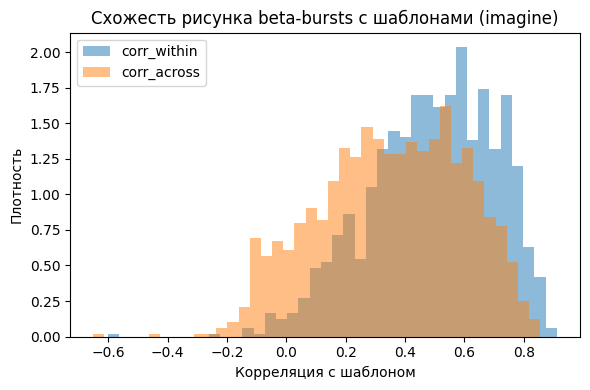

In [37]:
plt.figure(figsize=(6,4))
plt.hist(within, bins=40, alpha=0.5, label='corr_within', density=True)
plt.hist(across, bins=40, alpha=0.5, label='corr_across', density=True)
plt.xlabel('Корреляция с шаблоном')
plt.ylabel('Плотность')
plt.legend()
plt.title('Схожесть рисунка beta-bursts с шаблонами (imagine)')
plt.tight_layout()
plt.show()


In [38]:
# results_arr[i] = [power, phase, s_id, t_id, gender, handiness, age, label_val, img, task_type]

trial2sid   = {i: results_arr[i][2] for i in range(len(results_arr))}
trial2label = {i: results_arr[i][7] for i in range(len(results_arr))}

df_beta['s_id']      = df_beta['trial'].map(trial2sid)
df_beta['label_val'] = df_beta['trial'].map(trial2label)

df_beta_w['s_id']      = df_beta_w['trial'].map(trial2sid)
df_beta_w['label_val'] = df_beta_w['trial'].map(trial2label)


In [39]:
# только триалы с task_type == 'g' и окно воображения
df_g_img = df_beta_w[
    (df_beta_w['task_type'] == 'g') &
    (df_beta_w['win'] == 'imagine')
].copy()

print(df_g_img[['s_id','trial','label_val']].head())
print("Уникальных картинок (label_val):", sorted(df_g_img['label_val'].unique()))


   s_id  trial  label_val
0     5      0          2
1     5      0          2
2     5      0          2
4     5      0          2
6     5      0          2
Уникальных картинок (label_val): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [40]:
group_cols = ['s_id', 'trial', 'label_val', 'ch']

beta_g_trial_ch = (
    df_g_img
    .groupby(group_cols)['duration']
    .size()
    .reset_index(name='n_beta_bursts')
)

beta_g_mat = beta_g_trial_ch.pivot_table(
    index=['s_id', 'trial', 'label_val'],  # индекс = триал с метаданными
    columns='ch',
    values='n_beta_bursts',
    fill_value=0
)

print("beta_g_mat shape:", beta_g_mat.shape)
beta_g_mat.head()


beta_g_mat shape: (839, 63)


ch                     0    1    2    3    4    5    6    7    8    9   ...  \
s_id trial label_val                                                    ...   
1    168   9          0.0  0.0  0.0  0.0  0.0  1.0  0.0  1.0  1.0  0.0  ...   
     169   10         0.0  1.0  1.0  2.0  2.0  1.0  0.0  1.0  2.0  0.0  ...   
     170   10         0.0  0.0  0.0  0.0  1.0  1.0  1.0  1.0  0.0  0.0  ...   
     171   9          2.0  1.0  0.0  0.0  1.0  0.0  0.0  0.0  1.0  0.0  ...   
     172   10         1.0  1.0  1.0  0.0  1.0  1.0  1.0  1.0  2.0  0.0  ...   

ch                     53   54   55   56   57   58   59   60   61   62  
s_id trial label_val                                                    
1    168   9          0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  
     169   10         1.0  1.0  0.0  1.0  1.0  0.0  0.0  0.0  1.0  0.0  
     170   10         1.0  1.0  0.0  0.0  1.0  0.0  1.0  0.0  0.0  0.0  
     171   9          0.0  0.0  0.0  0.0  2.0  0.0  0.0  1.0  0.0  0.0  
     172   10         1.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  2.0  0.0  

[5 rows x 63 columns]

In [41]:
# доля всплесков на каждом канале
row_sums = beta_g_mat.sum(axis=1).replace(0, np.nan)
pattern_mat = beta_g_mat.div(row_sums, axis=0).fillna(0)

# метаданные по триалам
meta = pattern_mat.index.to_frame(index=False)
X    = pattern_mat.values          # (n_trials_g, n_channels)
labels = meta['label_val'].values  # лейблы картинок (0..12 или 1..13)

print("pattern_mat shape:", pattern_mat.shape)
meta.head()


pattern_mat shape: (839, 63)


,s_id,trial,label_val
0,1,168,9
1,1,169,10
2,1,170,10
3,1,171,9
4,1,172,10


In [42]:
# корреляция Пирсона между векторами-бёрст-паттернами
R = np.corrcoef(X)   # размер (N_trials, N_trials)
N = X.shape[0]

same_corrs = []
diff_corrs = []

for i in range(N):
    for j in range(i+1, N):
        if labels[i] == labels[j]:
            same_corrs.append(R[i, j])   # пары триалов с ОДНОЙ картинкой
        else:
            diff_corrs.append(R[i, j])   # пары с РАЗНЫМИ картинками

same_corrs = np.array(same_corrs)
diff_corrs = np.array(diff_corrs)

print("same_corrs mean:", same_corrs.mean())
print("diff_corrs mean:", diff_corrs.mean())
print("N_same:", len(same_corrs), "N_diff:", len(diff_corrs))

U, p = stats.mannwhitneyu(same_corrs, diff_corrs, alternative='greater')
print("Mann–Whitney (same > diff): U =", U, "p =", p)


same_corrs mean: 0.089678259545056
diff_corrs mean: 0.08623645353840605
N_same: 26816 N_diff: 324725
Mann–Whitney (same > diff): U = 4389327771.0 p = 0.01329962904649147


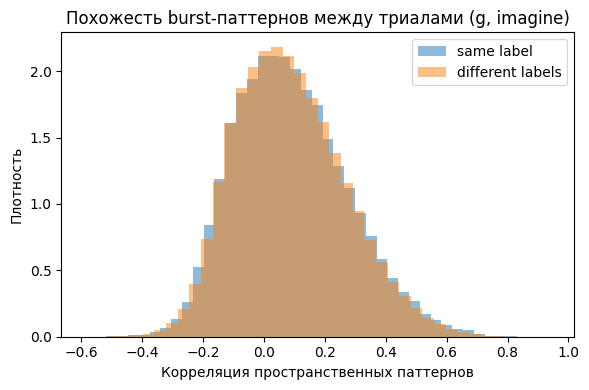

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(same_corrs, bins=40, alpha=0.5, density=True, label='same label')
plt.hist(diff_corrs, bins=40, alpha=0.5, density=True, label='different labels')
plt.xlabel('Корреляция пространственных паттернов')
plt.ylabel('Плотность')
plt.legend()
plt.title('Похожесть burst-паттернов между триалами (g, imagine)')
plt.tight_layout()
plt.show()


In [44]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

y = labels        # label_val (0..12 или 1..13)
X_features = X    # spatial-паттерны bursts (нормализованные по триалу)

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, multi_class='multinomial')
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X_features, y, cv=cv)

print("Mean accuracy:", scores.mean())
print("Std accuracy:", scores.std())
print("Chance level (1/13):", 1/13)


Mean accuracy: 0.08583547191331622
Std accuracy: 0.008306773714389816
Chance level (1/13): 0.07692307692307693


In [45]:
unique_labels = np.sort(np.unique(labels))

rows = []
for lbl in unique_labels:
    idx_L   = (labels == lbl)
    idx_not = (labels != lbl)

    n_L = idx_L.sum()
    if n_L < 2:
        # если для какой-то картинки меньше 2 триалов, внутри-корреляцию не посчитать
        continue

    # --- внутриклассовая корреляция (within) ---
    R_LL = R[np.ix_(idx_L, idx_L)]  # подматрица trials(label L) × trials(label L)
    # берём только верхний треугольник без диагонали
    iu = np.triu_indices(n_L, k=1)
    within_corrs_L = R_LL[iu]
    mean_within_L = float(np.mean(within_corrs_L))

    # --- межклассовая корреляция (across) ---
    if idx_not.sum() > 0:
        R_Lnot = R[np.ix_(idx_L, idx_not)]
        across_corrs_L = R_Lnot.ravel()
        mean_across_L = float(np.mean(across_corrs_L))
    else:
        mean_across_L = np.nan

    rows.append({
        'label_val': lbl,
        'n_trials': int(n_L),
        'mean_within': mean_within_L,
        'mean_across': mean_across_L,
        'diff_within_minus_across': mean_within_L - mean_across_L
    })

label_stats = pd.DataFrame(rows)
print(label_stats)


    label_val  n_trials  mean_within  mean_across  diff_within_minus_across
0           0        59     0.080687     0.079913                  0.000773
1           1        62     0.058301     0.073111                 -0.014810
2           2        65     0.078235     0.084402                 -0.006166
3           3        63     0.084585     0.086542                 -0.001958
4           4        75     0.146271     0.108236                  0.038035
5           5        69     0.111876     0.096347                  0.015529
6           6        67     0.073011     0.079767                 -0.006757
7           7        60     0.107363     0.096273                  0.011089
8           8        54     0.079557     0.084044                 -0.004488
9           9        66     0.071945     0.079949                 -0.008003
10         10        68     0.058954     0.069673                 -0.010719
11         11        65     0.073983     0.081995                 -0.008012
12         1

In [46]:
valid = label_stats.dropna(subset=['mean_within', 'mean_across']).copy()
diff = valid['mean_within'] - valid['mean_across']

print("Средняя разница по картинкам (within - across):", diff.mean())
print("По label’ам:")
print(valid[['label_val','n_trials','mean_within','mean_across','diff_within_minus_across']])

# парный тест по картинкам: within > across ?
W, p = stats.wilcoxon(diff, alternative='greater')
print("Wilcoxon по label’ам (within > across): W =", W, "p =", p)


Средняя разница по картинкам (within - across): 0.0019154640280439979
По label’ам:
    label_val  n_trials  mean_within  mean_across  diff_within_minus_across
0           0        59     0.080687     0.079913                  0.000773
1           1        62     0.058301     0.073111                 -0.014810
2           2        65     0.078235     0.084402                 -0.006166
3           3        63     0.084585     0.086542                 -0.001958
4           4        75     0.146271     0.108236                  0.038035
5           5        69     0.111876     0.096347                  0.015529
6           6        67     0.073011     0.079767                 -0.006757
7           7        60     0.107363     0.096273                  0.011089
8           8        54     0.079557     0.084044                 -0.004488
9           9        66     0.071945     0.079949                 -0.008003
10         10        68     0.058954     0.069673                 -0.010719
11   

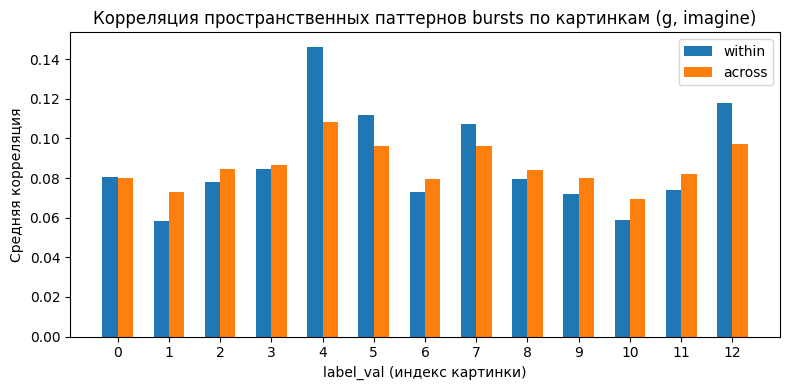

In [47]:
plt.figure(figsize=(8,4))
x = np.arange(len(valid))

plt.bar(x - 0.15, valid['mean_within'], width=0.3, label='within')
plt.bar(x + 0.15, valid['mean_across'], width=0.3, label='across')

plt.xticks(x, valid['label_val'])
plt.xlabel('label_val (индекс картинки)')
plt.ylabel('Средняя корреляция')
plt.title('Корреляция пространственных паттернов bursts по картинкам (g, imagine)')
plt.legend()
plt.tight_layout()
plt.show()


In [48]:
all_alpha = []

for trial_idx, trial in enumerate(results_arr):
    power, phase, s_id, t_id, gender, handiness, age, label_val, img, task_type = trial
    if power.ndim == 3:
        n_ch, n_freqs, n_times = power.shape
    elif power.ndim == 2:
        n_freqs, n_times = power.shape
    else:
        raise ValueError(f"Ожидалось 2D или 3D power, а получили shape={power.shape}")
    freqs = np.linspace(2, 40, n_freqs)  
    # время
    dt = 50 / 1000.0
    times = np.arange(power.shape[2]) * dt
    baseline_mask = times < 0 if np.any(times < 0) else None

    alpha_patterns = detect_power_patterns_per_channel(
        power, freqs, times,
        z_thresh=2.5,        # можно как в бете, при необходимости подправить
        min_dur=0.2,
        freq_range=(7, 13),  # <--- АЛЬФА
        baseline_mask=baseline_mask
    )

    for p in alpha_patterns:
        p['trial']     = trial_idx
        p['task_type'] = task_type
        p['label_val'] = label_val

    all_alpha.extend(alpha_patterns)

df_alpha = pd.DataFrame(all_alpha)
print("df_alpha shape:", df_alpha.shape)
print(df_alpha.head())


df_alpha shape: (6228, 8)
   ch  freq_low  freq_high  time_start  time_end  trial task_type  label_val
0   3  7.092784  12.185567        2.90      3.10     14         r         -1
1  44  7.092784   8.463918        3.25      3.40     17         r         -1
2  35  7.092784  12.577320        6.45      6.65     40         r         -1
3   3  7.092784  10.422680       17.30     17.50     43         g          1
4   8  7.092784  10.814433       17.30     17.45     43         g          1


In [49]:
trial2sid = {i: results_arr[i][2] for i in range(len(results_arr))}
trial2label = {i: results_arr[i][7] for i in range(len(results_arr))}

df_alpha['s_id']      = df_alpha['trial'].map(trial2sid)
df_alpha['label_val'] = df_alpha['trial'].map(trial2label)

In [50]:
def add_time_window(df, edges, labels):
    df = df.copy()
    t_mid = (df['time_start'] + df['time_end']) / 2.0
    df['win'] = pd.cut(
        t_mid,
        bins=edges,
        labels=labels,
        include_lowest=True,
        right=False
    )
    return df

edges  = [0.0, 0.5, 5.5, 20.5]
labels = ['command', 'imagine', 'rest2']

df_alpha_w = add_time_window(df_alpha, edges, labels)
print(df_alpha_w['win'].value_counts())

win
rest2      4542
imagine    1397
command     289
Name: count, dtype: int64


## Harmonic beta vs true beta

Цель: разделить наблюдаемую бета-активность на (1) бета как гармонику несинусоидальной альфы  и (2) настоящие бета/гамма-всплески,
и сравнить их информативность по паттерну (label_val) в окне воображения.

In [51]:
df_alpha_g_img = df_alpha_w[(df_alpha_w['task_type'] == 'g') & (df_alpha_w['win'] == 'imagine')].copy()
df_alpha_r_img = df_alpha_w[(df_alpha_w['task_type'] == 'r') & (df_alpha_w['win'] == 'imagine')].copy()

print("df_alpha_g_img:", df_alpha_g_img.shape, " | df_alpha_r_img:", df_alpha_r_img.shape)

df_alpha_g_img: (939, 10)  | df_alpha_r_img: (458, 10)


hb_beta_all: (173192, 19)
hb_has_alpha_match    0.022172
hb_is_harm            0.005664
Name: fraction, dtype: float64


hb_has_alpha_match  hb_is_harm
task_type win                                    
g         command            0.062306    0.011779
          imagine            0.015493    0.003649
          rest2              0.027188    0.007946
r         command            0.014380    0.004194
          imagine            0.022177    0.006331
          rest2              0.021487    0.003913

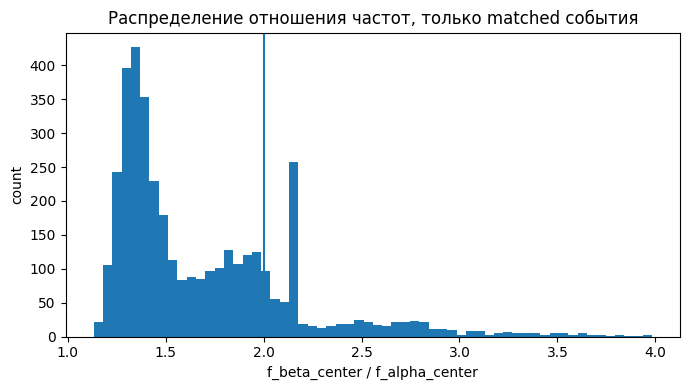

In [52]:
def _ensure_centers(df, f_low='freq_low', f_high='freq_high'):
    df = df.copy()
    df['f_center'] = (df[f_low] + df[f_high]) / 2.0
    return df

def _match_harmonic_beta(
    df_beta_events: pd.DataFrame,
    df_alpha_events: pd.DataFrame,
    min_overlap_s: float = 0.05,
    tol_hz: float = 2.0,
    ratio_tol: float = 0.15,
):
    """Для каждого бета-вспелска ищет лучший (по overlap) альфа-матч в том же (trial, ch).
    Возвращает копию df_beta_events с полями:
      - hb_has_alpha_match (bool)
      - hb_alpha_id (float/NaN)
      - hb_overlap_s (float/NaN)
      - hb_f_alpha (float/NaN)
      - hb_ratio_fbeta_falpha (float/NaN)
      - hb_is_harm (bool)
    """

    required = {'trial','ch','time_start','time_end','freq_low','freq_high'}
    missing_b = required - set(df_beta_events.columns)
    missing_a = required - set(df_alpha_events.columns)
    if missing_b:
        raise ValueError(f"df_beta_events missing columns: {sorted(missing_b)}")
    if missing_a:
        raise ValueError(f"df_alpha_events missing columns: {sorted(missing_a)}")

    b = _ensure_centers(df_beta_events)
    a = _ensure_centers(df_alpha_events)

    # сохраняем id, чтобы потом мёржить без плавающих сравнения по float
    b = b.copy()
    a = a.copy()
    b['hb_beta_id'] = b.index.astype(int)
    a['hb_alpha_id'] = a.index.astype(int)

    # заранее сгруппируем альфу по (trial, ch)
    a_groups = {}
    for (trial, ch), g in a.groupby(['trial','ch']):
        # сортировка по времени для небольшого ускорения
        a_groups[(trial, ch)] = g.sort_values('time_start')

    out_rows = []
    for (trial, ch), gb in b.groupby(['trial','ch']):
        ga = a_groups.get((trial, ch), None)
        if ga is None or len(ga) == 0:
            # нет альфы в этом trial/ch
            out_rows.append(pd.DataFrame({
                'hb_beta_id': gb['hb_beta_id'].values,
                'hb_has_alpha_match': False,
                'hb_alpha_id': np.nan,
                'hb_overlap_s': np.nan,
                'hb_f_alpha': np.nan,
                'hb_ratio_fbeta_falpha': np.nan,
                'hb_is_harm': False
            }))
            continue

        a_t0 = ga['time_start'].values
        a_t1 = ga['time_end'].values
        a_fc = ga['f_center'].values
        a_id = ga['hb_alpha_id'].values

        beta_ids = gb['hb_beta_id'].values
        b_t0 = gb['time_start'].values
        b_t1 = gb['time_end'].values
        b_fc = gb['f_center'].values

        # для каждого beta ищем кандидатов с пересечением по времени
        has_match = np.zeros(len(gb), dtype=bool)
        best_alpha_id = np.full(len(gb), np.nan)
        best_ovlp = np.full(len(gb), np.nan)
        best_fa = np.full(len(gb), np.nan)
        best_ratio = np.full(len(gb), np.nan)
        best_is_harm = np.zeros(len(gb), dtype=bool)

        for i in range(len(gb)):
            # overlap condition
            mask = (a_t0 < b_t1[i]) & (a_t1 > b_t0[i])
            if not np.any(mask):
                continue
            # overlap length
            ovlp = np.minimum(a_t1[mask], b_t1[i]) - np.maximum(a_t0[mask], b_t0[i])
            j = np.argmax(ovlp)
            if ovlp[j] < min_overlap_s:
                continue

            fa = a_fc[mask][j]
            ratio = b_fc[i] / fa if fa > 0 else np.nan

            # два критерия гармоники: |fбета - 2 fальфа| и ratio≈2
            is_harm = (abs(b_fc[i] - 2*fa) <= tol_hz) or (abs(ratio - 2.0) <= ratio_tol)

            has_match[i] = True
            best_alpha_id[i] = a_id[mask][j]
            best_ovlp[i] = ovlp[j]
            best_fa[i] = fa
            best_ratio[i] = ratio
            best_is_harm[i] = bool(is_harm)

        out_rows.append(pd.DataFrame({
            'hb_beta_id': beta_ids,
            'hb_has_alpha_match': has_match,
            'hb_alpha_id': best_alpha_id,
            'hb_overlap_s': best_ovlp,
            'hb_f_alpha': best_fa,
            'hb_ratio_fbeta_falpha': best_ratio,
            'hb_is_harm': best_is_harm
        }))

    matches = pd.concat(out_rows, ignore_index=True)

    # мёржим обратно в исходный df_beta_events по hb_beta_id
    b_out = b.merge(matches, on='hb_beta_id', how='left')

    b_out['hb_has_alpha_match'] = b_out['hb_has_alpha_match'].fillna(False)
    b_out['hb_is_harm'] = b_out['hb_is_harm'].fillna(False)

    return b_out

# применяем к бете: сравним все окна/условия, а для декодирования возьмём g+imagine 
hb_beta_all = _match_harmonic_beta(df_beta_w, df_alpha_w, min_overlap_s=0.05, tol_hz=2.0, ratio_tol=0.15)

print("hb_beta_all:", hb_beta_all.shape)
print(hb_beta_all[['hb_has_alpha_match','hb_is_harm']].mean().rename('fraction'))

# Доля гармонической беты по окнам и task_type
harm_stats = (
    hb_beta_all
    .groupby(['task_type','win'])[['hb_has_alpha_match','hb_is_harm']]
    .mean()
    .sort_index()
)
display(harm_stats)

# распределение отношения fбета/fальфа (только где есть match)
m = hb_beta_all[hb_beta_all['hb_has_alpha_match'] & hb_beta_all['hb_ratio_fbeta_falpha'].notna()].copy()

plt.figure(figsize=(7,4))
plt.hist(m['hb_ratio_fbeta_falpha'], bins=60)
plt.axvline(2.0)
plt.xlabel('f_beta_center / f_alpha_center')
plt.ylabel('count')
plt.title('Распределение отношения частот, только matched события')
plt.tight_layout()
plt.show()


In [53]:
total = len(hb_beta_all)
frac_match = hb_beta_all['hb_has_alpha_match'].mean()
frac_harm = hb_beta_all['hb_is_harm'].mean()

print("Total beta events:", total)
print("Matched beta events (count):", int(round(total * frac_match)))
print("Harm beta events (count):", int(round(total * frac_harm)))
print("Harm among matched (%):", 100 * frac_harm / frac_match)


Total beta events: 173192
Matched beta events (count): 3840
Harm beta events (count): 981
Harm among matched (%): 25.546875


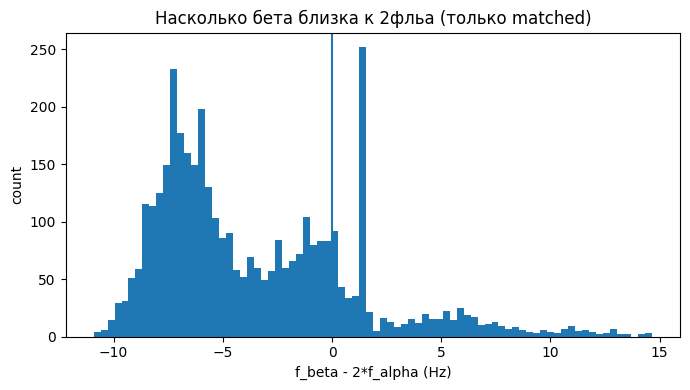

count    3840.000000
mean       -3.453310
std         4.566949
min       -10.912371
25%        -6.994845
50%        -4.938144
75%        -0.530928
max        14.649485
Name: delta, dtype: float64


In [54]:
m = hb_beta_all[hb_beta_all['hb_has_alpha_match'] & hb_beta_all['hb_f_alpha'].notna()].copy()
m['f_beta'] = (m['freq_low'] + m['freq_high']) / 2
m['delta'] = m['f_beta'] - 2*m['hb_f_alpha']

plt.figure(figsize=(7,4))
plt.hist(m['delta'], bins=80)
plt.axvline(0.0)
plt.xlabel('f_beta - 2*f_alpha (Hz)')
plt.ylabel('count')
plt.title('Насколько бета близка к 2фльа (только matched)')
plt.tight_layout()
plt.show()

print(m['delta'].describe())


In [55]:
for ov in [0.0, 0.01, 0.02, 0.05, 0.10]:
    hb_tmp = _match_harmonic_beta(df_beta_w, df_alpha_w, min_overlap_s=ov, tol_hz=2.0, ratio_tol=0.15)
    print("min_overlap_s =", ov,
          " match =", hb_tmp['hb_has_alpha_match'].mean(),
          " harm =", hb_tmp['hb_is_harm'].mean())


min_overlap_s = 0.0  match = 0.02273199685897732  harm = 0.005860547831308605
min_overlap_s = 0.01  match = 0.02273199685897732  harm = 0.005860547831308605
min_overlap_s = 0.02  match = 0.02273199685897732  harm = 0.005860547831308605
min_overlap_s = 0.05  match = 0.022171924800221718  harm = 0.005664233913806643
min_overlap_s = 0.1  match = 0.01986812323894868  harm = 0.005029100651300291


In [56]:
tmp = hb_beta_all[hb_beta_all['hb_has_alpha_match']].copy()
by = tmp.groupby(['task_type','win'])['hb_is_harm'].mean().rename('harm_among_matched')
display(by)


task_type  win    
g          command    0.189055
           imagine    0.235495
           rest2      0.292267
r          command    0.291667
           imagine    0.285479
           rest2      0.182119
Name: harm_among_matched, dtype: float64

In [57]:
def match_harmonic_beta_with_lag(
    df_beta_events,
    df_alpha_events,
    lag_s=0.10,      # допуск по времени ±100 мс
    tol_hz=2.0,
    ratio_tol=0.15
):
    b = df_beta_events.copy()
    a = df_alpha_events.copy()

    b['f_beta'] = (b['freq_low'] + b['freq_high']) / 2
    a['f_alpha'] = (a['freq_low'] + a['freq_high']) / 2

    b['beta_id'] = b.index.astype(int)
    a['alpha_id'] = a.index.astype(int)

    a_groups = {k: g for k, g in a.groupby(['trial','ch'])}

    out = []
    for (trial, ch), gb in b.groupby(['trial','ch']):
        ga = a_groups.get((trial, ch), None)
        if ga is None or len(ga) == 0:
            tmp = gb[['beta_id']].copy()
            tmp['has_alpha_near'] = False
            tmp['alpha_id'] = np.nan
            tmp['alpha_f'] = np.nan
            tmp['ratio'] = np.nan
            tmp['is_harm'] = False
            out.append(tmp)
            continue

        a0 = ga['time_start'].values
        a1 = ga['time_end'].values
        af = ga['f_alpha'].values
        aid = ga['alpha_id'].values

        bt0 = gb['time_start'].values
        bt1 = gb['time_end'].values
        bf  = gb['f_beta'].values

        best_alpha = np.full(len(gb), np.nan)
        best_af = np.full(len(gb), np.nan)
        best_ratio = np.full(len(gb), np.nan)
        best_is_harm = np.zeros(len(gb), dtype=bool)
        has_near = np.zeros(len(gb), dtype=bool)

        for i in range(len(gb)):
            # "near" если интервалы близко: alpha_end >= beta_start - lag и alpha_start <= beta_end + lag
            mask = (a1 >= bt0[i] - lag_s) & (a0 <= bt1[i] + lag_s)
            if not np.any(mask):
                continue

            # выбираем ближайшую по времени (по центрам)
            a_center = (a0[mask] + a1[mask]) / 2
            b_center = (bt0[i] + bt1[i]) / 2
            j = int(np.argmin(np.abs(a_center - b_center)))

            fa = af[mask][j]
            ratio = bf[i] / fa if fa > 0 else np.nan
            is_harm = (abs(bf[i] - 2*fa) <= tol_hz) or (abs(ratio - 2.0) <= ratio_tol)

            has_near[i] = True
            best_alpha[i] = aid[mask][j]
            best_af[i] = fa
            best_ratio[i] = ratio
            best_is_harm[i] = bool(is_harm)

        tmp = gb[['beta_id']].copy()
        tmp['has_alpha_near'] = has_near
        tmp['alpha_id'] = best_alpha
        tmp['alpha_f'] = best_af
        tmp['ratio'] = best_ratio
        tmp['is_harm'] = best_is_harm
        out.append(tmp)

    out = pd.concat(out, ignore_index=True)
    b2 = b.merge(out, on='beta_id', how='left')
    b2['has_alpha_near'] = b2['has_alpha_near'].fillna(False)
    b2['is_harm'] = b2['is_harm'].fillna(False)
    return b2


In [58]:
for lag in [0.0, 0.05, 0.10, 0.20, 0.30]:
    hb_lag = match_harmonic_beta_with_lag(df_beta_w, df_alpha_w, lag_s=lag, tol_hz=2.0, ratio_tol=0.15)
    print("lag_s =", lag,
          " alpha_near =", hb_lag['has_alpha_near'].mean(),
          " harm =", hb_lag['is_harm'].mean(),
          " harm_among_near =", hb_lag['is_harm'].mean() / max(hb_lag['has_alpha_near'].mean(), 1e-9))


lag_s = 0.0  alpha_near = 0.023690470691486904  harm = 0.006212758095062128  harm_among_near = 0.2622471362417743
lag_s = 0.05  alpha_near = 0.024458404545244585  harm = 0.006570742297565707  harm_among_near = 0.26864966949952784
lag_s = 0.1  alpha_near = 0.025174372950251742  harm = 0.006824795602568248  harm_among_near = 0.2711009174311927
lag_s = 0.2  alpha_near = 0.026490830985264908  harm = 0.007205875560072059  harm_among_near = 0.27201394943330426
lag_s = 0.3  alpha_near = 0.02817104716153171  harm = 0.007644694905076447  harm_among_near = 0.27136708341873333


In [59]:
lag = 0.3
hb_lag = match_harmonic_beta_with_lag(df_beta_w, df_alpha_w, lag_s=lag, tol_hz=2.0, ratio_tol=0.15)

# добавим task_type/win если они есть в df_beta_w (должны быть)
hb_lag_g_img = hb_lag[(hb_lag['task_type']=='g') & (hb_lag['win']=='imagine')].copy()

beta_harm = hb_lag_g_img[hb_lag_g_img['is_harm']].copy()
beta_true = hb_lag_g_img[~hb_lag_g_img['is_harm']].copy()

print("g+imagine beta events:", len(hb_lag_g_img))
print("beta_harm:", len(beta_harm), " | beta_true:", len(beta_true))
print("harm fraction (g+imagine):", len(beta_harm)/max(len(hb_lag_g_img),1))


g+imagine beta events: 56734
beta_harm: 301  | beta_true: 56433
harm fraction (g+imagine): 0.005305460570381076


In [60]:
import numpy as np
import pandas as pd

def unpack_trial_fixed(item):
    # [Power, Phase, Subject, Trial, Gender, Handiness, Age, Label, Image(6x6), Task_Type('g'/'r')]
    power = item[0]
    phase = item[1]
    s_id  = int(item[2])
    t_id  = int(item[3])
    gender = item[4]
    hand   = item[5]          # 'r'/'l' или None
    age    = int(item[6])
    label  = int(item[7])     # может быть str цифра -> int()
    img    = np.asarray(item[8])
    task   = item[9]          # 'g' или 'r'
    # валидации
    if task not in ("g","r"):
        raise ValueError(f"Unexpected task_type={task} (trial item len={len(item)})")
    if img.ndim != 2:
        raise ValueError(f"Unexpected img ndim={img.ndim}, shape={img.shape}")
    return power, phase, s_id, t_id, gender, hand, age, label, img, task

rows = []
for idx, item in enumerate(results_arr):
    power, phase, s_id, t_id, gender, hand, age, label, img, task = unpack_trial_fixed(item)
    rows.append({
        "trial_global": idx,          # индекс в results_arr
        "s_id": s_id,
        "trial_in_subject": t_id,
        "task_type": task,
        "label": label,
        "gender": gender,
        "handiness": hand,
        "age": age,
        "has_img": img is not None
    })

df_meta = pd.DataFrame(rows)
display(df_meta.head(10))
print(df_meta.groupby(["task_type","has_img"]).size())
print("labels(g) unique:", sorted(df_meta[df_meta.task_type=="g"]["label"].unique()))


,trial_global,s_id,trial_in_subject,task_type,label,gender,handiness,age,has_img
0,0,5,1,g,2,m,r,23,True
1,1,5,1,g,10,m,r,23,True
2,2,5,1,g,6,m,r,23,True
3,3,5,1,g,6,m,r,23,True
4,4,5,1,g,10,m,r,23,True
5,5,5,1,g,6,m,r,23,True
6,6,5,1,g,10,m,r,23,True
7,7,5,1,g,8,m,r,23,True
8,8,5,1,g,8,m,r,23,True
9,9,5,1,g,9,m,r,23,True


task_type  has_img
g          True       840
r          True       420
dtype: int64
labels(g) unique: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [61]:
def get_img36(trial_global):
    img = unpack_trial_fixed(results_arr[int(trial_global)])[8]  # поле Image
    return np.asarray(img, dtype=np.float32).reshape(-1)

df_g = df_meta[(df_meta.task_type=="g") & (df_meta.has_img)].copy()
trials_g = df_g["trial_global"].tolist()

Y = np.vstack([get_img36(t) for t in trials_g]).astype(np.float32)
print("g trials:", len(trials_g), "Y shape:", Y.shape)  # (n_trials, 36)


g trials: 840 Y shape: (840, 36)


In [62]:
import numpy as np
import pandas as pd

def _coalesce(df, out_col, candidates):
    """Создаёт out_col, беря первую существующую колонку из candidates."""
    for c in candidates:
        if c in df.columns:
            df[out_col] = df[c]
            return
    df[out_col] = np.nan

def attach_trial_global_v2(df_events, df_meta):
    """
    Возвращает df_events + стандартизированные колонки:
      trial_global, s_id, trial_in_subject, task_type, label
    Пробует 2 варианта матчинга:
      A) df_events.trial == df_meta.trial_global
      B) если есть s_id: (s_id, trial) == (s_id, trial_in_subject)
    """
    e = df_events.copy()
    if "trial" not in e.columns:
        raise ValueError("df_events must have column 'trial'")

    meta = df_meta[["trial_global","s_id","trial_in_subject","task_type","label"]].copy()

    # --- вариант A ---
    A = e.merge(meta, left_on="trial", right_on="trial_global", how="left", suffixes=("", "_m"))
    A = A.copy()
    _coalesce(A, "label_std", ["label_m", "label"])
    missA = A["label_std"].isna().mean()

    best = A
    best_miss = missA
    best_mode = "A: trial == trial_global"

    # --- вариант B ---
    if "s_id" in e.columns:
        B = e.merge(meta, left_on=["s_id","trial"], right_on=["s_id","trial_in_subject"], how="left", suffixes=("", "_m"))
        B = B.copy()
        _coalesce(B, "label_std", ["label_m", "label"])
        missB = B["label_std"].isna().mean()
        if missB < best_miss:
            best = B
            best_miss = missB
            best_mode = "B: (s_id,trial) == (s_id,trial_in_subject)"

    # --- нормализуем колонки ---
    out = best.copy()
    _coalesce(out, "trial_global_std", ["trial_global_m", "trial_global"])
    _coalesce(out, "s_id_std", ["s_id_m", "s_id"])
    _coalesce(out, "trial_in_subject_std", ["trial_in_subject_m", "trial_in_subject"])
    _coalesce(out, "task_type_std", ["task_type_m", "task_type"])

    out = out.drop(columns=[c for c in ["label_std"] if c in out.columns], errors="ignore")
    out = out.rename(columns={
        "trial_global_std": "trial_global",
        "s_id_std": "s_id",
        "trial_in_subject_std": "trial_in_subject",
        "task_type_std": "task_type",
    })

    # label: предпочитаем meta label (если был конфликт -> label_m), иначе label
    if "label_m" in out.columns:
        out["label"] = out["label_m"]
    # иначе label уже есть

    print("attach_trial_global_v2 ->", best_mode, "| missing label:", float(best_miss))
    return out


In [63]:
hb2 = attach_trial_global_v2(hb_lag, df_meta)
gm2 = attach_trial_global_v2(df_gamma_w, df_meta)

print("hb2 columns (check):", [c for c in ["trial","trial_global","s_id","trial_in_subject","task_type","label","win","ch"] if c in hb2.columns])
print("gm2 columns (check):", [c for c in ["trial","trial_global","s_id","trial_in_subject","task_type","label","win","ch"] if c in gm2.columns])

display(hb2[["trial","trial_global","s_id","task_type","label"]].head())
display(gm2[["trial","trial_global","s_id","task_type","label"]].head())


attach_trial_global_v2 -> A: trial == trial_global | missing label: 0.0
attach_trial_global_v2 -> A: trial == trial_global | missing label: 0.0
hb2 columns (check): ['trial', 'trial_global', 's_id', 'trial_in_subject', 'task_type', 'label', 'win', 'ch']
gm2 columns (check): ['trial', 'trial_global', 's_id', 'trial_in_subject', 'task_type', 'label', 'win', 'ch']


,trial,trial_global,trial_global,s_id,s_id,task_type,task_type,label
0,0,0,0,5,5,g,g,2
1,0,0,0,5,5,g,g,2
2,0,0,0,5,5,g,g,2
3,0,0,0,5,5,g,g,2
4,0,0,0,5,5,g,g,2


,trial,trial_global,trial_global,s_id,s_id,task_type,task_type,label
0,0,0,0,5,5,g,g,2
1,0,0,0,5,5,g,g,2
2,0,0,0,5,5,g,g,2
3,0,0,0,5,5,g,g,2
4,0,0,0,5,5,g,g,2


In [64]:
dups = hb2.columns[hb2.columns.duplicated()].unique()
print("Duplicate columns in hb2:", list(dups))

dups_g = gm2.columns[gm2.columns.duplicated()].unique()
print("Duplicate columns in gm2:", list(dups_g))


Duplicate columns in hb2: ['trial_global', 's_id', 'trial_in_subject', 'task_type']
Duplicate columns in gm2: ['trial_global', 's_id', 'trial_in_subject', 'task_type']


In [65]:
hb2 = hb2.loc[:, ~hb2.columns.duplicated(keep="last")].copy()
gm2 = gm2.loc[:, ~gm2.columns.duplicated(keep="last")].copy()

print("hb2 duplicate columns left:", hb2.columns[hb2.columns.duplicated()].unique())
print("gm2 duplicate columns left:", gm2.columns[gm2.columns.duplicated()].unique())


hb2 duplicate columns left: Index([], dtype='object')
gm2 duplicate columns left: Index([], dtype='object')


In [66]:
beta_true_cmd = hb2[(hb2['task_type']=='g') & (hb2['win']=='command') & (~hb2['is_harm'])].copy()
beta_true_img = hb2[(hb2['task_type']=='g') & (hb2['win']=='imagine') & (~hb2['is_harm'])].copy()

gamma_cmd = gm2[(gm2['task_type']=='g') & (gm2['win']=='command')].copy()
gamma_img = gm2[(gm2['task_type']=='g') & (gm2['win']=='imagine')].copy()

print("beta_true_cmd:", beta_true_cmd.shape, "beta_true_img:", beta_true_img.shape)
print("gamma_cmd:", gamma_cmd.shape, "gamma_img:", gamma_img.shape)


beta_true_cmd: (3183, 23) beta_true_img: (56433, 23)
gamma_cmd: (551, 15) gamma_img: (7284, 15)


In [67]:
def bursts_to_X(df_events, trials_global, channels, mode="count", normalize=True):
    d = df_events[df_events["trial_global"].isin(trials_global)].copy()

    if mode == "count":
        g = d.groupby(["trial_global","ch"]).size()
    elif mode == "duration":
        d["dur"] = d["time_end"] - d["time_start"]
        g = d.groupby(["trial_global","ch"])["dur"].sum()
    else:
        raise ValueError("mode must be 'count' or 'duration'")

    mat = g.unstack(fill_value=0)
    mat = mat.reindex(columns=channels, fill_value=0)
    mat = mat.reindex(trials_global, fill_value=0)

    X = mat.values.astype(np.float32)

    if normalize:
        rs = X.sum(axis=1, keepdims=True)
        rs[rs == 0] = 1.0
        X = X / rs

    return X

all_ch = sorted(pd.unique(pd.concat([
    beta_true_cmd["ch"], beta_true_img["ch"],
    gamma_cmd["ch"], gamma_img["ch"]
], ignore_index=True)))
print("n_channels:", len(all_ch))

mode = "count"  # попробуешь потом "duration"

Xb_cmd = bursts_to_X(beta_true_cmd, trials_g, all_ch, mode=mode, normalize=True)
Xg_cmd = bursts_to_X(gamma_cmd,    trials_g, all_ch, mode=mode, normalize=True)
X_cmd  = np.hstack([Xb_cmd, Xg_cmd])

Xb_img = bursts_to_X(beta_true_img, trials_g, all_ch, mode=mode, normalize=True)
Xg_img = bursts_to_X(gamma_img,    trials_g, all_ch, mode=mode, normalize=True)
X_img  = np.hstack([Xb_img, Xg_img])

print("X_cmd:", X_cmd.shape, "X_img:", X_img.shape, "Y:", Y.shape)


n_channels: 63
X_cmd: (840, 126) X_img: (840, 126) Y: (840, 36)


In [68]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import numpy as np

# группы/метки для CV (в порядке trials_g)
groups = df_g.set_index("trial_global").loc[trials_g, "s_id"].values
labels = df_g.set_index("trial_global").loc[trials_g, "label"].values

model = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))

pixel_corr = []
pixel_acc05 = []
retrieval_acc = []
examples = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_cmd, labels, groups=groups), start=1):
    # train: command -> image
    model.fit(X_cmd[tr_idx], Y[tr_idx])

    # test: imagine -> predicted image
    Yhat = model.predict(X_img[te_idx])
    Yte  = Y[te_idx]

    # 1) корреляция по 36 пикселям
    for i in range(len(te_idx)):
        a = Yte[i]; b = Yhat[i]
        ca = a - a.mean()
        cb = b - b.mean()
        denom = (np.linalg.norm(ca) * np.linalg.norm(cb) + 1e-9)
        pixel_corr.append(float(np.dot(ca, cb) / denom))

        # 2) бинарная точность (порог 0.5)
        a_bin = (a >= 0.5).astype(np.float32)
        b_bin = (b >= 0.5).astype(np.float32)
        pixel_acc05.append(float(np.mean(a_bin == b_bin)))

    # 3) retrieval accuracy внутри test-fold
    R = np.corrcoef(Yhat, Yte)[:len(te_idx), len(te_idx):]
    pred_best = np.argmax(R, axis=1)
    retrieval_acc.append(float(np.mean(pred_best == np.arange(len(te_idx)))))

    if fold == 1:
        for k in range(min(8, len(te_idx))):
            examples.append((Yte[k], Yhat[k]))

print("pixel_corr mean±std:", np.mean(pixel_corr), np.std(pixel_corr))
print("pixel_acc@0.5 mean±std:", np.mean(pixel_acc05), np.std(pixel_acc05))
print("retrieval_acc mean±std:", np.mean(retrieval_acc), np.std(retrieval_acc))


pixel_corr mean±std: 0.16621142741538214 0.3354293548758558
pixel_acc@0.5 mean±std: 0.5931547619047619 0.14681106259572915
retrieval_acc mean±std: 0.0035714285714285713 0.0029160592175990216


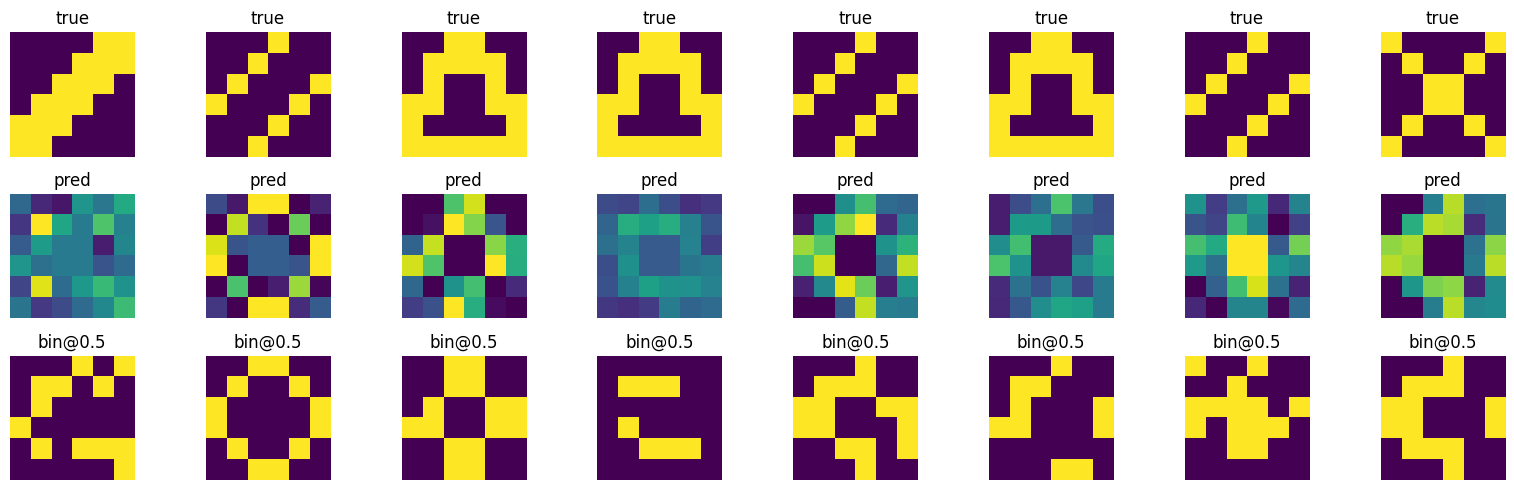

In [69]:
import matplotlib.pyplot as plt

def show_examples(examples, thr=0.5):
    n = min(8, len(examples))
    plt.figure(figsize=(2*n, 5))
    for i in range(n):
        yt, yh = examples[i]
        yt2 = yt.reshape(6,6)
        yh2 = yh.reshape(6,6)
        yh_bin = (yh2 >= thr).astype(float)

        plt.subplot(3, n, i+1)
        plt.imshow(yt2, vmin=0, vmax=1)
        plt.axis("off")
        plt.title("true")

        plt.subplot(3, n, n+i+1)
        plt.imshow(yh2, vmin=0, vmax=1)
        plt.axis("off")
        plt.title("pred")

        plt.subplot(3, n, 2*n+i+1)
        plt.imshow(yh_bin, vmin=0, vmax=1)
        plt.axis("off")
        plt.title(f"bin@{thr}")

    plt.tight_layout()
    plt.show()

show_examples(examples, thr=0.5)


In [70]:
from sklearn.model_selection import GroupKFold
import numpy as np

groups = df_g.set_index("trial_global").loc[trials_g, "s_id"].values
labels = df_g.set_index("trial_global").loc[trials_g, "label"].values

gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))

fold_info = []
for fold, (_, te_idx) in enumerate(gkf.split(np.zeros(len(trials_g)), labels, groups=groups), start=1):
    n = len(te_idx)
    fold_info.append((fold, n, 1/n))

print("fold, n_test, chance_trial_retrieval=1/n_test")
for x in fold_info:
    print(x)
print("mean chance:", np.mean([x[2] for x in fold_info]))


fold, n_test, chance_trial_retrieval=1/n_test
(1, 168, 0.005952380952380952)
(2, 168, 0.005952380952380952)
(3, 168, 0.005952380952380952)
(4, 168, 0.005952380952380952)
(5, 168, 0.005952380952380952)
mean chance: 0.005952380952380952


In [71]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold

# прототипы по label (true images)
lab_all = df_g.set_index("trial_global").loc[trials_g, "label"].values
uniq_lab = np.sort(np.unique(lab_all))

protos = {}
for lb in uniq_lab:
    protos[lb] = Y[lab_all == lb].mean(axis=0)

P = np.vstack([protos[lb] for lb in uniq_lab])  # (n_labels, 36)

def corr_to_protos(yhat, P):
    # yhat: (36,), P: (n_labels, 36)
    a = yhat - yhat.mean()
    B = P - P.mean(axis=1, keepdims=True)
    denom = (np.linalg.norm(a) * np.linalg.norm(B, axis=1) + 1e-9)
    return (B @ a) / denom  # (n_labels,)

model = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))

label_acc = []
pixel_corr = []
pixel_acc05 = []

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_cmd, labels, groups=groups), start=1):
    model.fit(X_cmd[tr_idx], Y[tr_idx])
    Yhat = model.predict(X_img[te_idx])
    Yte  = Y[te_idx]
    ylab = labels[te_idx]

    for i in range(len(te_idx)):
        # pixel corr
        a = Yte[i]; b = Yhat[i]
        ca = a - a.mean()
        cb = b - b.mean()
        pixel_corr.append(float(np.dot(ca, cb) / (np.linalg.norm(ca)*np.linalg.norm(cb) + 1e-9)))

        # pixel acc@0.5
        pixel_acc05.append(float(np.mean((a>=0.5) == (b>=0.5))))

        # label retrieval via prototypes
        sims = corr_to_protos(Yhat[i], P)
        pred_lb = uniq_lab[int(np.argmax(sims))]
        label_acc.append(float(pred_lb == ylab[i]))

print("pixel_corr mean±std:", np.mean(pixel_corr), np.std(pixel_corr))
print("pixel_acc@0.5 mean±std:", np.mean(pixel_acc05), np.std(pixel_acc05))
print("label/prototype retrieval acc:", np.mean(label_acc), " (chance ~", 1/len(uniq_lab), ")")


pixel_corr mean±std: 0.16621142741538214 0.3354293548758558
pixel_acc@0.5 mean±std: 0.5931547619047619 0.14681106259572915
label/prototype retrieval acc: 0.075  (chance ~ 0.07692307692307693 )


In [72]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GroupKFold
import numpy as np

def eval_Xcmd_Ximg(Xcmd, Ximg, Y, labels, groups, alpha=10.0):
    model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))

    corr_list, acc05_list, label_acc_list = [], [], []

    # prototypes
    uniq_lab = np.sort(np.unique(labels))
    protos = {lb: Y[labels == lb].mean(axis=0) for lb in uniq_lab}
    P = np.vstack([protos[lb] for lb in uniq_lab])

    def corr_to_protos(yhat):
        a = yhat - yhat.mean()
        B = P - P.mean(axis=1, keepdims=True)
        denom = (np.linalg.norm(a) * np.linalg.norm(B, axis=1) + 1e-9)
        return (B @ a) / denom

    for tr_idx, te_idx in gkf.split(Xcmd, labels, groups=groups):
        model.fit(Xcmd[tr_idx], Y[tr_idx])
        Yhat = model.predict(Ximg[te_idx])
        Yte  = Y[te_idx]
        ylab = labels[te_idx]

        for i in range(len(te_idx)):
            a = Yte[i]; b = Yhat[i]
            ca = a - a.mean(); cb = b - b.mean()
            corr_list.append(float(np.dot(ca, cb) / (np.linalg.norm(ca)*np.linalg.norm(cb) + 1e-9)))
            acc05_list.append(float(np.mean((a>=0.5) == (b>=0.5))))

            pred_lb = np.sort(np.unique(labels))[int(np.argmax(corr_to_protos(Yhat[i])))]
            label_acc_list.append(float(pred_lb == ylab[i]))

    return {
        "pixel_corr": (float(np.mean(corr_list)), float(np.std(corr_list))),
        "pixel_acc05": (float(np.mean(acc05_list)), float(np.std(acc05_list))),
        "label_acc": float(np.mean(label_acc_list)),
        "chance": 1/len(np.unique(labels))
    }

# X отдельно
X_beta_cmd = Xb_cmd
X_beta_img = Xb_img
X_gam_cmd  = Xg_cmd
X_gam_img  = Xg_img

res_beta = eval_Xcmd_Ximg(X_beta_cmd, X_beta_img, Y, labels, groups, alpha=10.0)
res_gam  = eval_Xcmd_Ximg(X_gam_cmd,  X_gam_img,  Y, labels, groups, alpha=10.0)
res_both = eval_Xcmd_Ximg(X_cmd,      X_img,      Y, labels, groups, alpha=10.0)

print("beta_true only:", res_beta)
print("gamma only    :", res_gam)
print("beta+gamma    :", res_both)


beta_true only: {'pixel_corr': (0.29019572817065203, 0.27062278076016405), 'pixel_acc05': (0.6481812169312169, 0.13300015833198142), 'label_acc': 0.06547619047619048, 'chance': 0.07692307692307693}
gamma only    : {'pixel_corr': (0.18990718013178387, 0.32312017762275885), 'pixel_acc05': (0.6053902116402117, 0.1491555024189066), 'label_acc': 0.0869047619047619, 'chance': 0.07692307692307693}
beta+gamma    : {'pixel_corr': (0.16621142741538214, 0.3354293548758558), 'pixel_acc05': (0.5931547619047619, 0.14681106259572915), 'label_acc': 0.075, 'chance': 0.07692307692307693}


In [73]:
import numpy as np
import pandas as pd

def bursts_to_X_timebins(df_events, trials_global, channels, n_bins=5, mode="count", normalize=True):
    d = df_events[df_events["trial_global"].isin(trials_global)].copy()
    if len(d) == 0:
        return np.zeros((len(trials_global), len(channels)*n_bins), dtype=np.float32)

    d["t_center"] = (d["time_start"] + d["time_end"]) / 2

    # биннинг по глобальному диапазону времени внутри этого df (то есть внутри конкретного win)
    tmin, tmax = float(d["t_center"].min()), float(d["t_center"].max())
    edges = np.linspace(tmin, tmax + 1e-9, n_bins + 1)
    d["bin"] = np.clip(np.digitize(d["t_center"], edges) - 1, 0, n_bins-1)

    if mode == "count":
        g = d.groupby(["trial_global","ch","bin"]).size().reset_index(name="v")
    else:
        d["dur"] = d["time_end"] - d["time_start"]
        g = d.groupby(["trial_global","ch","bin"])["dur"].sum().reset_index(name="v")

    # pivot -> columns = MultiIndex(ch,bin) потом выравниваем
    mat = g.pivot_table(index="trial_global", columns=["ch","bin"], values="v", fill_value=0)

    # создаём полный набор колонок
    full_cols = pd.MultiIndex.from_product([channels, range(n_bins)], names=["ch","bin"])
    mat = mat.reindex(columns=full_cols, fill_value=0)
    mat = mat.reindex(trials_global, fill_value=0)

    X = mat.values.astype(np.float32)

    if normalize:
        rs = X.sum(axis=1, keepdims=True)
        rs[rs == 0] = 1.0
        X = X / rs

    return X

n_bins = 5
mode = "count"

Xb_cmd_tb = bursts_to_X_timebins(beta_true_cmd, trials_g, all_ch, n_bins=n_bins, mode=mode, normalize=True)
Xg_cmd_tb = bursts_to_X_timebins(gamma_cmd,    trials_g, all_ch, n_bins=n_bins, mode=mode, normalize=True)
X_cmd_tb  = np.hstack([Xb_cmd_tb, Xg_cmd_tb])

Xb_img_tb = bursts_to_X_timebins(beta_true_img, trials_g, all_ch, n_bins=n_bins, mode=mode, normalize=True)
Xg_img_tb = bursts_to_X_timebins(gamma_img,    trials_g, all_ch, n_bins=n_bins, mode=mode, normalize=True)
X_img_tb  = np.hstack([Xb_img_tb, Xg_img_tb])

print("X_cmd_tb:", X_cmd_tb.shape, "X_img_tb:", X_img_tb.shape)

res_tb = eval_Xcmd_Ximg(X_cmd_tb, X_img_tb, Y, labels, groups, alpha=10.0)
print("time-binned beta+gamma:", res_tb)


X_cmd_tb: (840, 630) X_img_tb: (840, 630)
time-binned beta+gamma: {'pixel_corr': (0.0634349129230507, 0.3495735518092737), 'pixel_acc05': (0.5435846560846561, 0.15148562281927241), 'label_acc': 0.07142857142857142, 'chance': 0.07692307692307693}


In [74]:
# g trials
df_g = df_meta[(df_meta["task_type"]=="g") & (df_meta["has_img"])].copy()
trials_g = df_g["trial_global"].astype(int).tolist()

def get_img36(trial_global):
    # image лежит в results_arr по твоей структуре; если у тебя другая — поправь тут
    # В твоей последней рабочей версии ты уже доставала Y корректно.
    img = unpack_trial_fixed(results_arr[int(trial_global)])[8]  # поле Image
    return np.asarray(img, dtype=np.float32).reshape(-1)

Y = np.vstack([get_img36(t) for t in trials_g]).astype(np.float32)

labels = df_g.set_index("trial_global").loc[trials_g, "label"].astype(int).values
groups = df_g.set_index("trial_global").loc[trials_g, "s_id"].values

print("n_trials:", len(trials_g), "Y:", Y.shape, "n_labels:", len(np.unique(labels)), "n_subjects:", len(np.unique(groups)))
print("chance label:", 1/len(np.unique(labels)))


n_trials: 840 Y: (840, 36) n_labels: 13 n_subjects: 33
chance label: 0.07692307692307693


In [75]:
# hb2/gm2 должны содержать: trial_global, ch, win, task_type, is_harm
# и мы уже убрали дубликаты колонок.

beta_true_cmd = hb2[(hb2["task_type"]=="g") & (hb2["win"]=="command") & (~hb2["is_harm"])].copy()
beta_true_img = hb2[(hb2["task_type"]=="g") & (hb2["win"]=="imagine") & (~hb2["is_harm"])].copy()

gamma_cmd = gm2[(gm2["task_type"]=="g") & (gm2["win"]=="command")].copy()
gamma_img = gm2[(gm2["task_type"]=="g") & (gm2["win"]=="imagine")].copy()

all_ch = sorted(pd.unique(pd.concat([
    beta_true_cmd["ch"], beta_true_img["ch"], gamma_cmd["ch"], gamma_img["ch"]
], ignore_index=True)))

print("beta_true_cmd:", beta_true_cmd.shape, "beta_true_img:", beta_true_img.shape)
print("gamma_cmd:", gamma_cmd.shape, "gamma_img:", gamma_img.shape)
print("n_channels:", len(all_ch))



beta_true_cmd: (3183, 23) beta_true_img: (56433, 23)
gamma_cmd: (551, 15) gamma_img: (7284, 15)
n_channels: 63


In [76]:
def bursts_to_X_counts(df_events, trials_global, channels, use_log1p=True):
    d = df_events[df_events["trial_global"].isin(trials_global)].copy()
    g = d.groupby(["trial_global","ch"]).size()
    mat = g.unstack(fill_value=0)
    mat = mat.reindex(columns=channels, fill_value=0)
    mat = mat.reindex(trials_global, fill_value=0)
    X = mat.values.astype(np.float32)
    if use_log1p:
        X = np.log1p(X)
    return X

Xb_cmd = bursts_to_X_counts(beta_true_cmd, trials_g, all_ch, use_log1p=True)
Xb_img = bursts_to_X_counts(beta_true_img, trials_g, all_ch, use_log1p=True)

Xg_cmd = bursts_to_X_counts(gamma_cmd, trials_g, all_ch, use_log1p=True)
Xg_img = bursts_to_X_counts(gamma_img, trials_g, all_ch, use_log1p=True)

X_cmd_b = Xb_cmd
X_img_b = Xb_img

X_cmd_g = Xg_cmd
X_img_g = Xg_img

X_cmd_bg = np.hstack([Xb_cmd, Xg_cmd])
X_img_bg = np.hstack([Xb_img, Xg_img])

print(X_cmd_b.shape, X_cmd_g.shape, X_cmd_bg.shape)


(840, 63) (840, 63) (840, 126)


In [77]:
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

def eval_recon(Xcmd, Ximg, Y, labels, groups, ridge_alpha=10.0):
    uniq_lab = np.sort(np.unique(labels))
    protos = {lb: Y[labels == lb].mean(axis=0) for lb in uniq_lab}
    P = np.vstack([protos[lb] for lb in uniq_lab])  # (n_labels, 36)

    def corr_to_protos(yhat):
        a = yhat - yhat.mean()
        B = P - P.mean(axis=1, keepdims=True)
        denom = (np.linalg.norm(a) * np.linalg.norm(B, axis=1) + 1e-9)
        return (B @ a) / denom

    model = make_pipeline(StandardScaler(), Ridge(alpha=ridge_alpha))
    gkf = GroupKFold(n_splits=min(5, len(np.unique(groups))))

    corr_list, acc05_list, lab_acc_list = [], [], []

    for tr_idx, te_idx in gkf.split(Xcmd, labels, groups=groups):
        model.fit(Xcmd[tr_idx], Y[tr_idx])
        Yhat = model.predict(Ximg[te_idx])
        Yte  = Y[te_idx]
        ylab = labels[te_idx]

        for i in range(len(te_idx)):
            a = Yte[i]; b = Yhat[i]
            ca = a - a.mean(); cb = b - b.mean()
            corr_list.append(float(np.dot(ca, cb) / (np.linalg.norm(ca)*np.linalg.norm(cb) + 1e-9)))
            acc05_list.append(float(np.mean((a>=0.5) == (b>=0.5))))

            pred_lb = uniq_lab[int(np.argmax(corr_to_protos(Yhat[i])))]
            lab_acc_list.append(float(pred_lb == ylab[i]))

    return {
        "pixel_corr_mean": float(np.mean(corr_list)),
        "pixel_corr_std": float(np.std(corr_list)),
        "pixel_acc05_mean": float(np.mean(acc05_list)),
        "pixel_acc05_std": float(np.std(acc05_list)),
        "label_acc": float(np.mean(lab_acc_list)),
        "chance": 1/len(np.unique(labels)),
    }

print(eval_recon(X_cmd_b,  X_img_b,  Y, labels, groups, ridge_alpha=10.0))
print(eval_recon(X_cmd_g,  X_img_g,  Y, labels, groups, ridge_alpha=10.0))
print(eval_recon(X_cmd_bg, X_img_bg, Y, labels, groups, ridge_alpha=10.0))


{'pixel_corr_mean': 0.08342539426036666, 'pixel_corr_std': 0.3479817080621512, 'pixel_acc05_mean': 0.5537698412698412, 'pixel_acc05_std': 0.1494851066666588, 'label_acc': 0.06428571428571428, 'chance': 0.07692307692307693}
{'pixel_corr_mean': 0.11950307207405109, 'pixel_corr_std': 0.3445158979093326, 'pixel_acc05_mean': 0.5629298941798941, 'pixel_acc05_std': 0.15443961135881348, 'label_acc': 0.08333333333333333, 'chance': 0.07692307692307693}
{'pixel_corr_mean': 0.041706667808924215, 'pixel_corr_std': 0.3466635892726652, 'pixel_acc05_mean': 0.5286375661375661, 'pixel_acc05_std': 0.1507903293749125, 'label_acc': 0.0630952380952381, 'chance': 0.07692307692307693}


In [78]:
alphas = [0.1, 1, 3, 10, 30, 100, 300, 1000]
out = []

for a in alphas:
    r = eval_recon(X_cmd_b, X_img_b, Y, labels, groups, ridge_alpha=a)
    out.append(["beta_true", a, r["pixel_corr_mean"], r["pixel_acc05_mean"], r["label_acc"]])

for a in alphas:
    r = eval_recon(X_cmd_bg, X_img_bg, Y, labels, groups, ridge_alpha=a)
    out.append(["beta+gamma", a, r["pixel_corr_mean"], r["pixel_acc05_mean"], r["label_acc"]])

res_alpha = pd.DataFrame(out, columns=["model","alpha","pixel_corr","pixel_acc05","label_acc"])
display(res_alpha.sort_values(["model","pixel_corr"], ascending=[True, False]).head(10))
display(res_alpha.sort_values(["model","label_acc"], ascending=[True, False]).head(10))


,model,alpha,pixel_corr,pixel_acc05,label_acc
15,beta+gamma,1000.0,0.168741,0.603406,0.067857
14,beta+gamma,300.0,0.106103,0.566733,0.053571
13,beta+gamma,100.0,0.070719,0.547553,0.066667
12,beta+gamma,30.0,0.050691,0.533069,0.063095
11,beta+gamma,10.0,0.041707,0.528638,0.063095
10,beta+gamma,3.0,0.037406,0.525761,0.057143
9,beta+gamma,1.0,0.035990,0.524934,0.057143
8,beta+gamma,0.1,0.035318,0.524934,0.058333
7,beta_true,1000.0,0.199655,0.623677,0.077381
6,beta_true,300.0,0.142521,0.592030,0.071429


,model,alpha,pixel_corr,pixel_acc05,label_acc
15,beta+gamma,1000.0,0.168741,0.603406,0.067857
13,beta+gamma,100.0,0.070719,0.547553,0.066667
11,beta+gamma,10.0,0.041707,0.528638,0.063095
12,beta+gamma,30.0,0.050691,0.533069,0.063095
8,beta+gamma,0.1,0.035318,0.524934,0.058333
9,beta+gamma,1.0,0.035990,0.524934,0.057143
10,beta+gamma,3.0,0.037406,0.525761,0.057143
14,beta+gamma,300.0,0.106103,0.566733,0.053571
7,beta_true,1000.0,0.199655,0.623677,0.077381
5,beta_true,100.0,0.107615,0.570602,0.073810


In [79]:
def bursts_to_X_timebins_rel(df_events, trials_global, channels, n_bins=3, use_log1p=True):
    d = df_events[df_events["trial_global"].isin(trials_global)].copy()
    if len(d) == 0:
        return np.zeros((len(trials_global), len(channels)*n_bins), dtype=np.float32)

    d["t_center"] = (d["time_start"] + d["time_end"]) / 2

    # посчитаем min/max времени в этом win для каждого trial
    tt = d.groupby("trial_global")["t_center"].agg(["min","max"])
    d = d.join(tt, on="trial_global", rsuffix="_trial")

    # относительное время 0..1
    denom = (d["max"] - d["min"]).replace(0, np.nan)
    d["t_rel"] = (d["t_center"] - d["min"]) / denom
    d["t_rel"] = d["t_rel"].fillna(0.5)

    d["bin"] = np.clip((d["t_rel"] * n_bins).astype(int), 0, n_bins-1)

    g = d.groupby(["trial_global","ch","bin"]).size().reset_index(name="v")
    mat = g.pivot_table(index="trial_global", columns=["ch","bin"], values="v", fill_value=0)

    full_cols = pd.MultiIndex.from_product([channels, range(n_bins)], names=["ch","bin"])
    mat = mat.reindex(columns=full_cols, fill_value=0)
    mat = mat.reindex(trials_global, fill_value=0)

    X = mat.values.astype(np.float32)
    if use_log1p:
        X = np.log1p(X)
    return X

n_bins = 3
Xb_cmd_tb = bursts_to_X_timebins_rel(beta_true_cmd, trials_g, all_ch, n_bins=n_bins, use_log1p=True)
Xb_img_tb = bursts_to_X_timebins_rel(beta_true_img, trials_g, all_ch, n_bins=n_bins, use_log1p=True)
Xg_cmd_tb = bursts_to_X_timebins_rel(gamma_cmd,    trials_g, all_ch, n_bins=n_bins, use_log1p=True)
Xg_img_tb = bursts_to_X_timebins_rel(gamma_img,    trials_g, all_ch, n_bins=n_bins, use_log1p=True)

X_cmd_tb = np.hstack([Xb_cmd_tb, Xg_cmd_tb])
X_img_tb = np.hstack([Xb_img_tb, Xg_img_tb])

print("X_cmd_tb:", X_cmd_tb.shape)

for a in [10, 30, 100, 300, 1000]:
    r = eval_recon(X_cmd_tb, X_img_tb, Y, labels, groups, ridge_alpha=a)
    print("alpha", a, "->", r)


X_cmd_tb: (840, 378)
alpha 10 -> {'pixel_corr_mean': 0.02418756893623118, 'pixel_corr_std': 0.348841206865878, 'pixel_acc05_mean': 0.5169973544973545, 'pixel_acc05_std': 0.149088084368613, 'label_acc': 0.07023809523809524, 'chance': 0.07692307692307693}
alpha 30 -> {'pixel_corr_mean': 0.03510836270138045, 'pixel_corr_std': 0.34884598086059565, 'pixel_acc05_mean': 0.5230489417989418, 'pixel_acc05_std': 0.14946091631572075, 'label_acc': 0.08452380952380953, 'chance': 0.07692307692307693}
alpha 100 -> {'pixel_corr_mean': 0.05216440161331061, 'pixel_corr_std': 0.34801696627236167, 'pixel_acc05_mean': 0.5346560846560847, 'pixel_acc05_std': 0.15218287022629656, 'label_acc': 0.08095238095238096, 'chance': 0.07692307692307693}
alpha 300 -> {'pixel_corr_mean': 0.07591682127350259, 'pixel_corr_std': 0.346168233365323, 'pixel_acc05_mean': 0.5491071428571429, 'pixel_acc05_std': 0.14846526537364144, 'label_acc': 0.08452380952380953, 'chance': 0.07692307692307693}
alpha 1000 -> {'pixel_corr_mean': 0

In [80]:
# Пересобери список геометрических trials и Y, чтобы гарантировать соответствие
df_g = df_meta[(df_meta["task_type"]=="g") & (df_meta["has_img"])].copy()
trials_g = df_g["trial_global"].astype(int).tolist()

Y = np.vstack([get_img36(t) for t in trials_g]).astype(np.float32)
labels = df_g.set_index("trial_global").loc[trials_g, "label"].astype(int).values
groups = df_g.set_index("trial_global").loc[trials_g, "s_id"].values

print("n_trials_g:", len(trials_g), "Y:", Y.shape, "X_cmd_tb rows should be:", len(trials_g))
print("labels unique:", np.unique(labels))


n_trials_g: 840 Y: (840, 36) X_cmd_tb rows should be: 840
labels unique: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]


In [81]:
import numpy as np
import pandas as pd

def bursts_to_X_temporal_moments(df_events, trials_global, channels, use_log1p=True):
    d = df_events[df_events["trial_global"].isin(trials_global)].copy()
    if len(d) == 0:
        return np.zeros((len(trials_global), len(channels)*3), dtype=np.float32)

    d["t_center"] = (d["time_start"] + d["time_end"]) / 2

    # относительное время внутри trial: 0..1
    tt = d.groupby("trial_global")["t_center"].agg(["min","max"])
    d = d.join(tt, on="trial_global", rsuffix="_trial")
    denom = (d["max"] - d["min"]).replace(0, np.nan)
    d["t_rel"] = ((d["t_center"] - d["min"]) / denom).fillna(0.5)

    # агрегируем по (trial, ch)
    agg = d.groupby(["trial_global","ch"]).agg(
        count=("t_rel","size"),
        t_mean=("t_rel","mean"),
        t_std=("t_rel","std"),
    ).reset_index()
    agg["t_std"] = agg["t_std"].fillna(0.0)

    # pivot по каналам -> потом склеим блоками [count|mean|std]
    def pivot(col):
        m = agg.pivot_table(index="trial_global", columns="ch", values=col, fill_value=0.0)
        m = m.reindex(columns=channels, fill_value=0.0)
        m = m.reindex(trials_global, fill_value=0.0)
        return m.values.astype(np.float32)

    Xc = pivot("count")
    if use_log1p:
        Xc = np.log1p(Xc)
    Xm = pivot("t_mean")
    Xs = pivot("t_std")

    return np.hstack([Xc, Xm, Xs])

# пересобери beta_true_cmd/img и gamma_cmd/img (как раньше) — но убедись, что trial_global есть
Xb_cmd_m = bursts_to_X_temporal_moments(beta_true_cmd, trials_g, all_ch)
Xb_img_m = bursts_to_X_temporal_moments(beta_true_img, trials_g, all_ch)
Xg_cmd_m = bursts_to_X_temporal_moments(gamma_cmd,    trials_g, all_ch)
Xg_img_m = bursts_to_X_temporal_moments(gamma_img,    trials_g, all_ch)

X_cmd_m = np.hstack([Xb_cmd_m, Xg_cmd_m])
X_img_m = np.hstack([Xb_img_m, Xg_img_m])

print("X_cmd_m:", X_cmd_m.shape)

for a in [10, 30, 100, 300, 1000]:
    r = eval_recon(X_cmd_m, X_img_m, Y, labels, groups, ridge_alpha=a)
    print("alpha", a, "->", r)


X_cmd_m: (840, 378)
alpha 10 -> {'pixel_corr_mean': 0.04850429045208756, 'pixel_corr_std': 0.35970127677773694, 'pixel_acc05_mean': 0.5223544973544973, 'pixel_acc05_std': 0.1524105162201564, 'label_acc': 0.07857142857142857, 'chance': 0.07692307692307693}
alpha 30 -> {'pixel_corr_mean': 0.0672530636854916, 'pixel_corr_std': 0.35609125549297094, 'pixel_acc05_mean': 0.5321428571428571, 'pixel_acc05_std': 0.1526371922398289, 'label_acc': 0.07261904761904762, 'chance': 0.07692307692307693}
alpha 100 -> {'pixel_corr_mean': 0.09065712864802965, 'pixel_corr_std': 0.3481717713591831, 'pixel_acc05_mean': 0.5474537037037037, 'pixel_acc05_std': 0.1516721104013001, 'label_acc': 0.07142857142857142, 'chance': 0.07692307692307693}
alpha 300 -> {'pixel_corr_mean': 0.11743901484107538, 'pixel_corr_std': 0.3392615641597368, 'pixel_acc05_mean': 0.5624338624338624, 'pixel_acc05_std': 0.14813314833361432, 'label_acc': 0.07261904761904762, 'chance': 0.07692307692307693}
alpha 1000 -> {'pixel_corr_mean': 0.

In [82]:
# Y: (n_trials, 36)
Ymean = Y.mean(axis=0, keepdims=True)
Yhat = np.repeat(Ymean, repeats=Y.shape[0], axis=0)

# pixel corr
corr = []
acc05 = []
for i in range(Y.shape[0]):
    a = Y[i]; b = Yhat[i]
    ca = a - a.mean(); cb = b - b.mean()
    corr.append(float(np.dot(ca, cb) / (np.linalg.norm(ca)*np.linalg.norm(cb) + 1e-9)))
    acc05.append(float(np.mean((a>=0.5) == (b>=0.5))))

print("MEAN-IMAGE baseline pixel_corr mean±std:", np.mean(corr), np.std(corr))
print("MEAN-IMAGE baseline pixel_acc@0.5 mean±std:", np.mean(acc05), np.std(acc05))


MEAN-IMAGE baseline pixel_corr mean±std: 0.32472187747998815 0.2457729672004551
MEAN-IMAGE baseline pixel_acc@0.5 mean±std: 0.6648148148148149 0.14157542796283915


In [83]:
def bin_metrics(y_true, y_pred, thr=0.5):
    yt = (y_true >= 0.5)
    yp = (y_pred >= thr)

    tp = np.sum(yt & yp)
    fp = np.sum(~yt & yp)
    fn = np.sum(yt & ~yp)

    iou = tp / (tp + fp + fn + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1 = 2*prec*rec / (prec + rec + 1e-9)
    return float(iou), float(f1), float(prec), float(rec)

# пример: посчитаем для твоих предсказаний из последнего фолда (если сохранила Yhat/Yte — если нет, см. ниже)


In [84]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import numpy as np

def eval_within_subject(Xcmd, Ximg, Y, labels, groups, ridge_alpha=10.0, thr=0.5):
    uniq_lab = np.sort(np.unique(labels))
    protos = {lb: Y[labels == lb].mean(axis=0) for lb in uniq_lab}
    P = np.vstack([protos[lb] for lb in uniq_lab])

    def corr_to_protos(yhat):
        a = yhat - yhat.mean()
        B = P - P.mean(axis=1, keepdims=True)
        denom = (np.linalg.norm(a) * np.linalg.norm(B, axis=1) + 1e-9)
        return (B @ a) / denom

    model = make_pipeline(StandardScaler(), Ridge(alpha=ridge_alpha))

    pix_corr, ious, f1s, lab_acc = [], [], [], []
    per_subj = []

    for sid in np.unique(groups):
        idx = np.where(groups == sid)[0]
        if len(idx) < 5:
            continue

        # train на command внутри субъекта
        model.fit(Xcmd[idx], Y[idx])
        Yhat = model.predict(Ximg[idx])
        Yte  = Y[idx]
        ylab = labels[idx]

        # метрики
        for i in range(len(idx)):
            a = Yte[i]; b = Yhat[i]
            ca = a - a.mean(); cb = b - b.mean()
            pix_corr.append(float(np.dot(ca, cb) / (np.linalg.norm(ca)*np.linalg.norm(cb) + 1e-9)))

            iou, f1, prec, rec = bin_metrics(a, b, thr=thr)
            ious.append(iou); f1s.append(f1)

            pred_lb = uniq_lab[int(np.argmax(corr_to_protos(b)))]
            lab_acc.append(float(pred_lb == ylab[i]))

        per_subj.append((sid, len(idx)))

    return {
        "n_subjects_used": len(per_subj),
        "pixel_corr_mean": float(np.mean(pix_corr)),
        "IoU_mean": float(np.mean(ious)),
        "F1_mean": float(np.mean(f1s)),
        "label_acc": float(np.mean(lab_acc)),
        "chance": 1/len(np.unique(labels)),
        "subjects": per_subj[:10],
    }

# Подставь сюда лучший X (например beta_true без timebins: X_cmd_b / X_img_b)
print(eval_within_subject(X_cmd_b, X_img_b, Y, labels, groups, ridge_alpha=10.0, thr=0.5))


{'n_subjects_used': 33, 'pixel_corr_mean': 0.13702962958616302, 'IoU_mean': 0.3347822608809041, 'F1_mean': 0.46254125260595697, 'label_acc': 0.1488095238095238, 'chance': 0.07692307692307693, 'subjects': [(1, 28), (2, 28), (3, 28), (4, 28), (5, 28), (6, 28), (7, 28), (8, 28), (9, 28), (10, 28)]}


In [85]:
import numpy as np

def perm_test_within_subject_labelacc(Xcmd, Ximg, Y, labels, groups, ridge_alpha=10.0, n_perm=200, seed=0):
    rng = np.random.default_rng(seed)

    # наблюдаемая
    obs = eval_within_subject(Xcmd, Ximg, Y, labels, groups, ridge_alpha=ridge_alpha, thr=0.5)["label_acc"]

    null = []
    for _ in range(n_perm):
        lab_perm = labels.copy()
        for sid in np.unique(groups):
            idx = np.where(groups == sid)[0]
            lab_perm[idx] = rng.permutation(lab_perm[idx])
        null.append(eval_within_subject(Xcmd, Ximg, Y, lab_perm, groups, ridge_alpha=ridge_alpha, thr=0.5)["label_acc"])

    null = np.array(null)
    p = (np.sum(null >= obs) + 1) / (len(null) + 1)

    return obs, null.mean(), null.std(), p

obs, m, s, p = perm_test_within_subject_labelacc(X_cmd_b, X_img_b, Y, labels, groups, ridge_alpha=10.0, n_perm=200)
print("obs label_acc:", obs, "| null mean±std:", m, s, "| p-value:", p)


obs label_acc: 0.1488095238095238 | null mean±std: 0.10126190476190476 0.011323700387955807 | p-value: 0.004975124378109453


In [86]:
ths = [0.2,0.3,0.4,0.5,0.6,0.7,0.8]
rows = []
for thr in ths:
    r = eval_within_subject(X_cmd_b, X_img_b, Y, labels, groups, ridge_alpha=10.0, thr=thr)
    rows.append([thr, r["IoU_mean"], r["F1_mean"], r["label_acc"]])

df_thr = pd.DataFrame(rows, columns=["thr","IoU","F1","label_acc"])
display(df_thr.sort_values("F1", ascending=False))


,thr,IoU,F1,label_acc
0,0.2,0.372800,0.515644,0.14881
1,0.3,0.361664,0.500098,0.14881
2,0.4,0.351047,0.483596,0.14881
3,0.5,0.334782,0.462541,0.14881
4,0.6,0.313665,0.437470,0.14881
5,0.7,0.289622,0.408111,0.14881
6,0.8,0.262793,0.373291,0.14881


In [87]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def eval_within_subject_pls(Xcmd, Ximg, Y, labels, groups, n_comp=10, thr=0.5):
    uniq_lab = np.sort(np.unique(labels))
    protos = {lb: Y[labels == lb].mean(axis=0) for lb in uniq_lab}
    P = np.vstack([protos[lb] for lb in uniq_lab])

    def corr_to_protos(yhat):
        a = yhat - yhat.mean()
        B = P - P.mean(axis=1, keepdims=True)
        denom = (np.linalg.norm(a) * np.linalg.norm(B, axis=1) + 1e-9)
        return (B @ a) / denom

    model = make_pipeline(StandardScaler(), PLSRegression(n_components=n_comp))

    pix_corr, ious, f1s, lab_acc = [], [], [], []

    for sid in np.unique(groups):
        idx = np.where(groups == sid)[0]
        if len(idx) < 5:
            continue

        model.fit(Xcmd[idx], Y[idx])
        Yhat = model.predict(Ximg[idx])
        Yte  = Y[idx]
        ylab = labels[idx]

        for i in range(len(idx)):
            a = Yte[i]; b = Yhat[i]
            ca = a - a.mean(); cb = b - b.mean()
            pix_corr.append(float(np.dot(ca, cb) / (np.linalg.norm(ca)*np.linalg.norm(cb) + 1e-9)))

            iou, f1, _, _ = bin_metrics(a, b, thr=thr)
            ious.append(iou); f1s.append(f1)

            pred_lb = uniq_lab[int(np.argmax(corr_to_protos(b)))]
            lab_acc.append(float(pred_lb == ylab[i]))

    return {
        "pixel_corr_mean": float(np.mean(pix_corr)),
        "IoU_mean": float(np.mean(ious)),
        "F1_mean": float(np.mean(f1s)),
        "label_acc": float(np.mean(lab_acc)),
        "chance": 1/len(np.unique(labels))
    }

# sweep по числу компонент
for k in [2,4,6,8,10,12,15]:
    r = eval_within_subject_pls(X_cmd_b, X_img_b, Y, labels, groups, n_comp=k, thr=0.5)
    print("PLS n_comp", k, "->", r)


PLS n_comp 2 -> {'pixel_corr_mean': 0.15743108936623582, 'IoU_mean': 0.33068270498920904, 'F1_mean': 0.45399596847299123, 'label_acc': 0.12380952380952381, 'chance': 0.07692307692307693}
PLS n_comp 4 -> {'pixel_corr_mean': 0.12062072139804962, 'IoU_mean': 0.324704496485341, 'F1_mean': 0.4501849080023524, 'label_acc': 0.1357142857142857, 'chance': 0.07692307692307693}
PLS n_comp 6 -> {'pixel_corr_mean': 0.12119763652002531, 'IoU_mean': 0.33204313578021316, 'F1_mean': 0.4602203047751683, 'label_acc': 0.12738095238095237, 'chance': 0.07692307692307693}
PLS n_comp 8 -> {'pixel_corr_mean': 0.10206753121775197, 'IoU_mean': 0.3328328994014125, 'F1_mean': 0.4638249174397534, 'label_acc': 0.14285714285714285, 'chance': 0.07692307692307693}
PLS n_comp 10 -> {'pixel_corr_mean': 0.09831412191212842, 'IoU_mean': 0.32780717286232275, 'F1_mean': 0.45881685982454984, 'label_acc': 0.12976190476190477, 'chance': 0.07692307692307693}
PLS n_comp 12 -> {'pixel_corr_mean': 0.0858402642998519, 'IoU_mean': 0.

ValueError: `n_components` upper bound is 14. Got 15 instead. Reduce `n_components`.

In [88]:
print("Ridge beta only:", eval_within_subject(X_cmd_b,  X_img_b,  Y, labels, groups, ridge_alpha=10.0, thr=0.2))
print("Ridge gamma only:", eval_within_subject(X_cmd_g,  X_img_g,  Y, labels, groups, ridge_alpha=10.0, thr=0.2))
print("Ridge beta+gamma:", eval_within_subject(X_cmd_bg, X_img_bg, Y, labels, groups, ridge_alpha=10.0, thr=0.2))


Ridge beta only: {'n_subjects_used': 33, 'pixel_corr_mean': 0.13702962958616302, 'IoU_mean': 0.37279952688314055, 'F1_mean': 0.5156437970688263, 'label_acc': 0.1488095238095238, 'chance': 0.07692307692307693, 'subjects': [(1, 28), (2, 28), (3, 28), (4, 28), (5, 28), (6, 28), (7, 28), (8, 28), (9, 28), (10, 28)]}
Ridge gamma only: {'n_subjects_used': 33, 'pixel_corr_mean': 0.3407313405543686, 'IoU_mean': 0.4350364645304965, 'F1_mean': 0.5837402669631789, 'label_acc': 0.1738095238095238, 'chance': 0.07692307692307693, 'subjects': [(1, 28), (2, 28), (3, 28), (4, 28), (5, 28), (6, 28), (7, 28), (8, 28), (9, 28), (10, 28)]}
Ridge beta+gamma: {'n_subjects_used': 33, 'pixel_corr_mean': 0.14283915858655818, 'IoU_mean': 0.3706056943582695, 'F1_mean': 0.5128351089599072, 'label_acc': 0.1619047619047619, 'chance': 0.07692307692307693, 'subjects': [(1, 28), (2, 28), (3, 28), (4, 28), (5, 28), (6, 28), (7, 28), (8, 28), (9, 28), (10, 28)]}


In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

def eval_within_subject_classif(Xcmd, Ximg, labels, groups, C=1.0):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=C, class_weight="balanced"))
    accs = []
    for sid in np.unique(groups):
        idx = np.where(groups == sid)[0]
        if len(np.unique(labels[idx])) < 2:
            continue
        clf.fit(Xcmd[idx], labels[idx])
        pred = clf.predict(Ximg[idx])
        accs.append(np.mean(pred == labels[idx]))
    return float(np.mean(accs)), float(np.std(accs))

for C in [0.1, 0.3, 1, 3, 10]:
    m, s = eval_within_subject_classif(X_cmd_b, X_img_b, labels, groups, C=C)
    print("LogReg beta-only C=", C, "acc mean±std:", m, s, "| chance:", 1/len(np.unique(labels)))


LogReg beta-only C= 0.1 acc mean±std: 0.14718614718614717 0.05681560497145752 | chance: 0.07692307692307693
LogReg beta-only C= 0.3 acc mean±std: 0.15367965367965367 0.06723906738964963 | chance: 0.07692307692307693
LogReg beta-only C= 1 acc mean±std: 0.1590909090909091 0.07038793308012598 | chance: 0.07692307692307693
LogReg beta-only C= 3 acc mean±std: 0.16125541125541124 0.06985341802209924 | chance: 0.07692307692307693
LogReg beta-only C= 10 acc mean±std: 0.1590909090909091 0.0714777477314215 | chance: 0.07692307692307693


In [90]:
# Xb_cmd_m, Xb_img_m должны быть посчитаны (moments только beta_true)
for a in [30, 100, 300, 1000, 3000]:
    r = eval_within_subject(Xb_cmd_m, Xb_img_m, Y, labels, groups, ridge_alpha=a, thr=0.2)
    print("beta-moments alpha", a, "->", r)


beta-moments alpha 30 -> {'n_subjects_used': 33, 'pixel_corr_mean': 0.15596844100381596, 'IoU_mean': 0.3845663794905976, 'F1_mean': 0.5283958489398514, 'label_acc': 0.15357142857142858, 'chance': 0.07692307692307693, 'subjects': [(1, 28), (2, 28), (3, 28), (4, 28), (5, 28), (6, 28), (7, 28), (8, 28), (9, 28), (10, 28)]}
beta-moments alpha 100 -> {'n_subjects_used': 33, 'pixel_corr_mean': 0.2010309812393537, 'IoU_mean': 0.4001196300039882, 'F1_mean': 0.5471089096069557, 'label_acc': 0.15833333333333333, 'chance': 0.07692307692307693, 'subjects': [(1, 28), (2, 28), (3, 28), (4, 28), (5, 28), (6, 28), (7, 28), (8, 28), (9, 28), (10, 28)]}
beta-moments alpha 300 -> {'n_subjects_used': 33, 'pixel_corr_mean': 0.2608090455301437, 'IoU_mean': 0.41896342089799754, 'F1_mean': 0.570180219548738, 'label_acc': 0.15476190476190477, 'chance': 0.07692307692307693, 'subjects': [(1, 28), (2, 28), (3, 28), (4, 28), (5, 28), (6, 28), (7, 28), (8, 28), (9, 28), (10, 28)]}
beta-moments alpha 1000 -> {'n_sub

In [91]:
from scipy.ndimage import gaussian_filter1d
def bursts_to_point_process(df_events, trials, channels, t0, t1, bin_ms=10):
    """
    df_events: таблица событий burst со столбцами trial_global, ch, time_start, time_end (сек)
    возвращает X: (n_trials, n_channels, n_bins) binary {0,1}
    """
    trials = [int(t) for t in trials]
    ch2i = {ch:i for i,ch in enumerate(channels)}
    tr2i = {tr:i for i,tr in enumerate(trials)}

    n_bins = int(np.ceil((t1 - t0) * 1000.0 / bin_ms))
    X = np.zeros((len(trials), len(channels), n_bins), dtype=np.float32)

    d = df_events[df_events["trial_global"].isin(trials)].copy()
    if len(d) == 0:
        return X

    # клип по времени
    ts = d["time_start"].astype(float).values
    te = d["time_end"].astype(float).values

    # переводим в бины
    bs = np.floor((ts - t0) * 1000.0 / bin_ms).astype(int)
    be = np.ceil((te - t0) * 1000.0 / bin_ms).astype(int)
    bs = np.clip(bs, 0, n_bins-1)
    be = np.clip(be, 0, n_bins)

    for (tr, ch, b0, b1) in zip(d["trial_global"].values, d["ch"].values, bs, be):
        if tr not in tr2i or ch not in ch2i:
            continue
        if b1 <= b0:
            b1 = min(b0+1, n_bins)
        X[tr2i[int(tr)], ch2i[ch], b0:b1] = 1.0

    return X

def smooth_point_process(X, sigma_ms=50, bin_ms=10):
    # статья сглаживала point process гауссом 50ms :contentReference[oaicite:7]{index=7}
    sigma_bins = sigma_ms / bin_ms
    return gaussian_filter1d(X, sigma=sigma_bins, axis=-1, mode="nearest")


In [92]:
def fit_label_components_from_command(X_cmd, y_label, n_comp=6, keep_frac=0.6):
    """
    X_cmd: (n_trials, n_ch, n_t) после smoothing
    y_label: (n_trials,)
    Возвращает W: (n_ch, n_comp) + средний шаблон mu(ch,t)
    """
    y = np.asarray(y_label).astype(int)
    labs = np.sort(np.unique(y))
    n_ch = X_cmd.shape[1]
    n_t  = X_cmd.shape[2]

    # mean по label
    M = np.zeros((len(labs), n_ch, n_t), dtype=np.float32)
    for i,lb in enumerate(labs):
        idx = np.where(y == lb)[0]
        M[i] = X_cmd[idx].mean(axis=0)

    mu = M.mean(axis=0, keepdims=False)                # (ch,t)
    L  = M - mu[None, :, :]                            # label-эффект

    # матрица для SVD: (ch) x (label*t)
    A = L.transpose(1,0,2).reshape(n_ch, -1)
    # SVD / PCA
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    W = U[:, :n_comp].copy()                           # (ch, comp)

    # sparsify веса как в статье (они выкидывали часть электродов, чтобы не переобучаться) :contentReference[oaicite:9]{index=9}
    if keep_frac is not None and 0 < keep_frac < 1:
        k_keep = max(1, int(np.ceil(keep_frac * n_ch)))
        for c in range(W.shape[1]):
            w = W[:, c]
            thr = np.partition(np.abs(w), -k_keep)[-k_keep]
            w[np.abs(w) < thr] = 0.0
            # нормируем
            norm = np.linalg.norm(w)
            if norm > 0:
                w /= norm
            W[:, c] = w

    return W, mu

def project_trials(X, W, mu=None):
    """
    X:  (n_trials, n_ch, n_t)
    W:  (n_ch, n_comp)
    mu: (n_ch, n_t) или None — если задано, вычитаем (как центрирование)
    -> Z: (n_trials, n_comp, n_t)
    """
    if mu is not None:
        X = X - mu[None, :, :]
    return np.einsum("nct,cp->npt", X, W)

In [93]:
def dpca_like_decode_within_subject(
    df_cmd, df_img, trials_g, labels, groups,
    channels, bin_ms=10, sigma_ms=50,
    n_comp=6, keep_frac=0.6, C=1.0
):
    # фиксируем общий тайм-диапазон, чтобы cmd/img имели одинаковую длину
    t0 = float(min(df_cmd["time_start"].min(), df_img["time_start"].min()))
    t1 = float(max(df_cmd["time_end"].max(),   df_img["time_end"].max()))

    accs = []
    for sid in np.unique(groups):
        idx = np.where(groups == sid)[0]
        if len(idx) < 8:
            continue

        tr_sub = [int(trials_g[i]) for i in idx]
        y_sub  = labels[idx].astype(int)

        # point process
        Xc = bursts_to_point_process(df_cmd, tr_sub, channels, t0, t1, bin_ms=bin_ms)
        Xi = bursts_to_point_process(df_img, tr_sub, channels, t0, t1, bin_ms=bin_ms)

        # smoothing ~50ms как у них :contentReference[oaicite:11]{index=11}
        Xc = smooth_point_process(Xc, sigma_ms=sigma_ms, bin_ms=bin_ms)
        Xi = smooth_point_process(Xi, sigma_ms=sigma_ms, bin_ms=bin_ms)

        # учим label-компоненты только на command (как “веса сессии” → применяем на imagine) :contentReference[oaicite:12]{index=12}
        W, mu = fit_label_components_from_command(Xc, y_sub, n_comp=n_comp, keep_frac=keep_frac)

        # проекция
        Zc = project_trials(Xc, W)  # (trial, comp, time)
        Zi = project_trials(Xi, W)

        # фичи: flatten comp*time (можно потом сжать/усреднить)
        Fc = Zc.reshape(len(idx), -1)
        Fi = Zi.reshape(len(idx), -1)

        # классификатор label: train command -> test imagine
        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=3000, C=C, class_weight="balanced", multi_class="auto")
        )
        clf.fit(Fc, y_sub)
        pred = clf.predict(Fi)
        accs.append(np.mean(pred == y_sub))

    return float(np.mean(accs)), float(np.std(accs)), len(accs)

# gamma-only
mean_acc, std_acc, nsub = dpca_like_decode_within_subject(
    gamma_cmd, gamma_img,
    trials_g=trials_g, labels=labels, groups=groups,
    channels=all_ch, bin_ms=10, sigma_ms=50,
    n_comp=6, keep_frac=0.6, C=1.0
)
print("dPCA-like gamma label acc within-subject:", mean_acc, "±", std_acc, "| n_subjects:", nsub, "| chance:", 1/len(np.unique(labels)))


dPCA-like gamma label acc within-subject: 0.11688311688311688 ± 0.07370439759299316 | n_subjects: 33 | chance: 0.07692307692307693


In [94]:
def residualize_within_subject(X, groups):
    """
    Вычитает mean по субъекту (по всем trials этого субъекта).
    Это убирает стабильные пространственные предпочтения/дрейф.
    """
    Xr = X.copy().astype(np.float32)
    for sid in np.unique(groups):
        idx = np.where(groups == sid)[0]
        Xr[idx] -= Xr[idx].mean(axis=0, keepdims=True)
    return Xr

# пример для gamma counts:
X_cmd_g_r = residualize_within_subject(X_cmd_g, groups)
X_img_g_r = residualize_within_subject(X_img_g, groups)

print("Ridge gamma only (residualized):",
      eval_within_subject(X_cmd_g_r, X_img_g_r, Y, labels, groups, ridge_alpha=10.0, thr=0.2))


Ridge gamma only (residualized): {'n_subjects_used': 33, 'pixel_corr_mean': 0.33154345802195234, 'IoU_mean': 0.431596038023076, 'F1_mean': 0.5833758221981528, 'label_acc': 0.18095238095238095, 'chance': 0.07692307692307693, 'subjects': [(1, 28), (2, 28), (3, 28), (4, 28), (5, 28), (6, 28), (7, 28), (8, 28), (9, 28), (10, 28)]}


In [95]:
def remove_top_components(X, k=5):
    """
    Удаляет первые k PCA-компонент (на данных X).
    Возвращает очищенные данные + компоненты.
    """
    Xc = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    V = Vt[:k]                 # (k, n_feat)
    proj = Xc @ V.T @ V        # проекция на top-k
    Xclean = Xc - proj
    return Xclean

# обучаем subspace на command (gamma)
Xcmd_clean = remove_top_components(X_cmd_g, k=5)
Ximg_clean = remove_top_components(X_img_g, k=5)  # можно так же, или вычитать mean command

print("Ridge gamma (remove top-k):",
      eval_within_subject(Xcmd_clean, Ximg_clean, Y, labels, groups, ridge_alpha=10.0, thr=0.2))


Ridge gamma (remove top-k): {'n_subjects_used': 33, 'pixel_corr_mean': 0.17715958425815936, 'IoU_mean': 0.38667201546880275, 'F1_mean': 0.5305388501442084, 'label_acc': 0.16666666666666666, 'chance': 0.07692307692307693, 'subjects': [(1, 28), (2, 28), (3, 28), (4, 28), (5, 28), (6, 28), (7, 28), (8, 28), (9, 28), (10, 28)]}


In [96]:
obs, m, s, p = perm_test_within_subject_labelacc(
    X_cmd_g_r, X_img_g_r, Y, labels, groups,
    ridge_alpha=10.0, n_perm=500, seed=0
)
print("GAMMA residualized obs:", obs, "| null mean±std:", m, s, "| p:", p)


GAMMA residualized obs: 0.18095238095238095 | null mean±std: 0.1317833333333333 0.014324490825679145 | p: 0.001996007984031936


In [97]:
def residualize_within_subject_separately(Xcmd, Ximg, groups):
    Xc = Xcmd.copy().astype(np.float32)
    Xi = Ximg.copy().astype(np.float32)
    for sid in np.unique(groups):
        idx = np.where(groups == sid)[0]
        Xc[idx] -= Xc[idx].mean(axis=0, keepdims=True)
        Xi[idx] -= Xi[idx].mean(axis=0, keepdims=True)
    return Xc, Xi

X_cmd_g_r2, X_img_g_r2 = residualize_within_subject_separately(X_cmd_g, X_img_g, groups)

print(eval_within_subject(X_cmd_g_r2, X_img_g_r2, Y, labels, groups, ridge_alpha=10.0, thr=0.2))


{'n_subjects_used': 33, 'pixel_corr_mean': 0.33154345802195234, 'IoU_mean': 0.431596038023076, 'F1_mean': 0.5833758221981528, 'label_acc': 0.18095238095238095, 'chance': 0.07692307692307693, 'subjects': [(1, 28), (2, 28), (3, 28), (4, 28), (5, 28), (6, 28), (7, 28), (8, 28), (9, 28), (10, 28)]}


In [98]:
def select_topk_channels_anova(Xcmd, y, n_ch, k=20):
    # Xcmd: (n_trials, n_ch)
    scores = np.zeros(n_ch, dtype=np.float32)
    for j in range(n_ch):
        groups_vals = [Xcmd[y==lb, j] for lb in np.unique(y)]
        # если какие-то классы пустые — пропускаем
        if any(len(g)==0 for g in groups_vals):
            scores[j] = 0
            continue
        F, p = stats.f_oneway(*groups_vals)
        scores[j] = F if np.isfinite(F) else 0
    idx = np.argsort(scores)[::-1][:k]
    return idx

def eval_within_subject_classif_topk(Xcmd, Ximg, labels, groups, k=20, C=1.0):
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LogisticRegression

    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=C, class_weight="balanced"))
    accs = []
    for sid in np.unique(groups):
        idx = np.where(groups == sid)[0]
        if len(idx) < 8:
            continue
        y = labels[idx]
        if len(np.unique(y)) < 2:
            continue

        top = select_topk_channels_anova(Xcmd[idx], y, Xcmd.shape[1], k=k)
        clf.fit(Xcmd[idx][:, top], y)
        pred = clf.predict(Ximg[idx][:, top])
        accs.append(np.mean(pred == y))
    return float(np.mean(accs)), float(np.std(accs))

# используем gamma residualized counts (X_cmd_g_r / X_img_g_r)
for k in [10, 15, 20, 30, 40]:
    m, s = eval_within_subject_classif_topk(X_cmd_g_r, X_img_g_r, labels, groups, k=k, C=1.0)
    print("top-k", k, "logreg label acc:", m, "±", s, "| chance:", 1/13)


top-k 10 logreg label acc: 0.14718614718614717 ± 0.08422111020928016 | chance: 0.07692307692307693
top-k 15 logreg label acc: 0.15692640692640694 ± 0.08877098118792157 | chance: 0.07692307692307693
top-k 20 logreg label acc: 0.158008658008658 ± 0.08249280952450003 | chance: 0.07692307692307693
top-k 30 logreg label acc: 0.15476190476190474 ± 0.07748494510679112 | chance: 0.07692307692307693
top-k 40 logreg label acc: 0.16017316017316013 ± 0.08015967180580608 | chance: 0.07692307692307693


In [99]:
Yb = (Y >= 0.5).astype(np.int8)   # (n_trials, 36)
print("Yb unique:", np.unique(Yb))
print("Yb shape:", Yb.shape)


Yb unique: [0 1]
Yb shape: (840, 36)


In [100]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def corr_to_protos(yhat, P):
    # yhat: (36,), P: (n_labels,36)
    a = yhat - yhat.mean()
    B = P - P.mean(axis=1, keepdims=True)
    denom = (np.linalg.norm(a) * np.linalg.norm(B, axis=1) + 1e-9)
    return (B @ a) / denom

def bin_metrics(y_true, y_prob, thr=0.5):
    yt = (y_true >= 0.5)
    yp = (y_prob >= thr)

    tp = np.sum(yt & yp)
    fp = np.sum(~yt & yp)
    fn = np.sum(yt & ~yp)

    iou = tp / (tp + fp + fn + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1 = 2*prec*rec / (prec + rec + 1e-9)
    return float(iou), float(f1)

def pixelwise_logreg_within_subject(Xcmd, Ximg, Yb, labels, groups, thr=0.5, C=1.0):
    uniq_lab = np.sort(np.unique(labels))
    # прототипы истинных картинок (для label_acc)
    protos = {lb: Yb[labels == lb].mean(axis=0) for lb in uniq_lab}
    P = np.vstack([protos[lb] for lb in uniq_lab])  # (n_labels,36)

    # логрег модель (маленькие выборки -> liblinear обычно норм)
    base = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, solver="liblinear", C=C)
    )

    all_iou, all_f1, all_lab = [], [], []
    # если захочешь потом посмотреть среднюю карту вероятностей:
    # probs_all = np.zeros_like(Yb, dtype=np.float32)

    for sid in np.unique(groups):
        idx = np.where(groups == sid)[0]
        if len(idx) < 8:
            continue

        Xtr = Xcmd[idx]
        Xte = Ximg[idx]
        Ytr = Yb[idx]   # (n_trials_sub,36)
        ylab = labels[idx]

        # предсказанные вероятности для imagine (n_trials_sub,36)
        Yprob = np.zeros((len(idx), 36), dtype=np.float32)

        # учим 36 независимых пикселей
        for p in range(36):
            y = Ytr[:, p]
            # если пиксель константа в train у субъекта — модель не обучить; прогноз константой
            if np.all(y == y[0]):
                Yprob[:, p] = float(y[0])
                continue
            m = base
            m.fit(Xtr, y)
            Yprob[:, p] = m.predict_proba(Xte)[:, 1]

        # метрики по trial
        for i in range(len(idx)):
            iou, f1 = bin_metrics(Ytr[i], Yprob[i], thr=thr)
            all_iou.append(iou)
            all_f1.append(f1)

            # label через сравнение с прототипами
            sims = corr_to_protos(Yprob[i], P)
            pred_lb = uniq_lab[int(np.argmax(sims))]
            all_lab.append(float(pred_lb == ylab[i]))

        # probs_all[idx] = Yprob  # если нужно

    return {
        "IoU_mean": float(np.mean(all_iou)),
        "F1_mean": float(np.mean(all_f1)),
        "label_acc": float(np.mean(all_lab)),
        "chance": 1/len(np.unique(labels)),
    }


In [101]:
ths = [0.2, 0.3, 0.4, 0.5, 0.6]
for thr in ths:
    r = pixelwise_logreg_within_subject(X_cmd_g_r, X_img_g_r, Yb, labels, groups, thr=thr, C=1.0)
    print("thr", thr, "->", r)


thr 0.2 -> {'IoU_mean': 0.4114910257906641, 'F1_mean': 0.5618545304565251, 'label_acc': 0.175, 'chance': 0.07692307692307693}
thr 0.3 -> {'IoU_mean': 0.4215444594615683, 'F1_mean': 0.565026433616578, 'label_acc': 0.175, 'chance': 0.07692307692307693}
thr 0.4 -> {'IoU_mean': 0.42052270217637205, 'F1_mean': 0.5552885409328738, 'label_acc': 0.175, 'chance': 0.07692307692307693}
thr 0.5 -> {'IoU_mean': 0.3922400478031878, 'F1_mean': 0.5209484822520773, 'label_acc': 0.175, 'chance': 0.07692307692307693}
thr 0.6 -> {'IoU_mean': 0.3315247663009136, 'F1_mean': 0.4528495101943806, 'label_acc': 0.175, 'chance': 0.07692307692307693}


In [102]:
def pixelwise_logreg_with_pixel_thresholds(Xcmd, Ximg, Yb, labels, groups, C=1.0, th_grid=None):
    if th_grid is None:
        th_grid = np.linspace(0.1, 0.9, 9)

    uniq_lab = np.sort(np.unique(labels))
    protos = {lb: Yb[labels == lb].mean(axis=0) for lb in uniq_lab}
    P = np.vstack([protos[lb] for lb in uniq_lab])

    base = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, solver="liblinear", C=C)
    )

    all_iou, all_f1, all_lab = [], [], []

    for sid in np.unique(groups):
        idx = np.where(groups == sid)[0]
        if len(idx) < 8:
            continue

        Xtr = Xcmd[idx]
        Xte = Ximg[idx]
        Ytr = Yb[idx]
        ylab = labels[idx]

        Yprob_te = np.zeros((len(idx), 36), dtype=np.float32)
        thr_pix = np.full(36, 0.5, dtype=np.float32)

        for p in range(36):
            y = Ytr[:, p]
            if np.all(y == y[0]):
                Yprob_te[:, p] = float(y[0])
                thr_pix[p] = 0.5
                continue

            m = base
            m.fit(Xtr, y)

            # вероятности на train (для подбора thr) и test
            prob_tr = m.predict_proba(Xtr)[:, 1]
            prob_te = m.predict_proba(Xte)[:, 1]
            Yprob_te[:, p] = prob_te

            # подобрать thr по F1 на train
            best_f1, best_thr = -1, 0.5
            for thr in th_grid:
                iou, f1 = bin_metrics(y, prob_tr, thr=thr)
                if f1 > best_f1:
                    best_f1, best_thr = f1, thr
            thr_pix[p] = best_thr

        # trial-level метрики
        for i in range(len(idx)):
            # бинаризуем с thr по пикселям
            yhat_bin = (Yprob_te[i] >= thr_pix).astype(np.int8)
            yt = Ytr[i].astype(np.int8)

            tp = np.sum((yt==1) & (yhat_bin==1))
            fp = np.sum((yt==0) & (yhat_bin==1))
            fn = np.sum((yt==1) & (yhat_bin==0))
            iou = tp / (tp + fp + fn + 1e-9)
            prec = tp / (tp + fp + 1e-9)
            rec  = tp / (tp + fn + 1e-9)
            f1 = 2*prec*rec / (prec + rec + 1e-9)

            all_iou.append(float(iou))
            all_f1.append(float(f1))

            sims = corr_to_protos(Yprob_te[i], P)
            pred_lb = uniq_lab[int(np.argmax(sims))]
            all_lab.append(float(pred_lb == ylab[i]))

    return {
        "IoU_mean": float(np.mean(all_iou)),
        "F1_mean": float(np.mean(all_f1)),
        "label_acc": float(np.mean(all_lab)),
        "chance": 1/len(np.unique(labels)),
    }

print(pixelwise_logreg_with_pixel_thresholds(X_cmd_g_r, X_img_g_r, Yb, labels, groups, C=1.0))


{'IoU_mean': 0.40833245196242046, 'F1_mean': 0.5622809880784776, 'label_acc': 0.175, 'chance': 0.07692307692307693}


In [103]:
Cs = [0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
ths = [0.2, 0.3, 0.4]

for C in Cs:
    best = None
    for thr in ths:
        r = pixelwise_logreg_within_subject(X_cmd_g_r, X_img_g_r, Yb, labels, groups, thr=thr, C=C)
        score = r["F1_mean"]
        if (best is None) or (score > best[0]):
            best = (score, thr, r)
    print("C=", C, "best thr=", best[1], "->", best[2])


C= 0.03 best thr= 0.2 -> {'IoU_mean': 0.39738825121791765, 'F1_mean': 0.5588207328762808, 'label_acc': 0.16904761904761906, 'chance': 0.07692307692307693}
C= 0.1 best thr= 0.4 -> {'IoU_mean': 0.4227464296496536, 'F1_mean': 0.5681303011128852, 'label_acc': 0.1738095238095238, 'chance': 0.07692307692307693}
C= 0.3 best thr= 0.3 -> {'IoU_mean': 0.4174326385283863, 'F1_mean': 0.5661941547179115, 'label_acc': 0.1773809523809524, 'chance': 0.07692307692307693}
C= 1.0 best thr= 0.3 -> {'IoU_mean': 0.4215444594615683, 'F1_mean': 0.565026433616578, 'label_acc': 0.175, 'chance': 0.07692307692307693}
C= 3.0 best thr= 0.2 -> {'IoU_mean': 0.414141909937323, 'F1_mean': 0.5611751933470833, 'label_acc': 0.16666666666666666, 'chance': 0.07692307692307693}
C= 10.0 best thr= 0.2 -> {'IoU_mean': 0.4093960373727575, 'F1_mean': 0.5538207252273103, 'label_acc': 0.1595238095238095, 'chance': 0.07692307692307693}


In [104]:
OUT = "features_gamma.npz"

needed = ["X_cmd_g_r","X_img_g_r", "X_cmd_tb", "X_img_tb", "Y","labels","groups"]
missing = [v for v in needed if v not in globals()]
if missing:
    print("Не вижу переменные в текущем kernel:", missing)
else:
    np.savez_compressed(
        OUT,
        X_cmd=np.asarray(X_cmd_g_r, dtype=np.float32),
        X_img=np.asarray(X_img_g_r, dtype=np.float32),
        X_cmd_tb = np.asarray(X_img_g_r, dtype=np.float32),
        X_img_tb = np.asarray(X_img_g_r, dtype=np.float32),
        Y=np.asarray(Y, dtype=np.float32),
        labels=np.asarray(labels, dtype=np.int64),
        groups=np.asarray(groups, dtype=np.int64),
    )
    print("Saved:", OUT, " size MB:", os.path.getsize(OUT)/1e6)


Saved: features_gamma.npz  size MB: 0.071717


In [105]:
print("gamma_cmd:", gamma_cmd.shape, "unique wins:", gamma_cmd["win"].unique() if "win" in gamma_cmd.columns else "no win col")
print("gamma_img:", gamma_img.shape, "unique wins:", gamma_img["win"].unique() if "win" in gamma_img.columns else "no win col")

# кол-во событий на один и тот же trial_global
if "trial_global" in gamma_cmd.columns and "trial_global" in gamma_img.columns:
    same_trials = np.intersect1d(gamma_cmd["trial_global"].unique(), gamma_img["trial_global"].unique())
    print("same trial_global count:", len(same_trials))


gamma_cmd: (551, 15) unique wins: ['command']
Categories (3, object): ['command' < 'imagine' < 'rest2']
gamma_img: (7284, 15) unique wins: ['imagine']
Categories (3, object): ['command' < 'imagine' < 'rest2']
same trial_global count: 188


In [106]:
def quick_stats(name, X):
    X = np.asarray(X)
    print(f"{name}: shape={X.shape} sum={X.sum():.3f} nnz={(X!=0).sum()} row_sums(min/med/max)={np.min(X.sum(1)):.3f}/{np.median(X.sum(1)):.3f}/{np.max(X.sum(1)):.3f}")

quick_stats("X_cmd_tb", X_cmd_tb)
quick_stats("X_img_tb", X_img_tb)

# покажем первые 3 строки (если вдруг там всё нули)
print("first rows cmd:\n", X_cmd_tb[:3])
print("first rows img:\n", X_img_tb[:3])


X_cmd_tb: shape=(840, 378) sum=2581.595 nnz=3711 row_sums(min/med/max)=0.000/0.693/72.846
X_img_tb: shape=(840, 378) sum=38369.375 nnz=45853 row_sums(min/med/max)=0.000/35.501/196.450
first rows cmd:
 [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
first rows img:
 [[0.6931472 0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]]


In [107]:
import numpy as np

cmd_zero = np.mean(X_cmd_tb.sum(axis=1) == 0)
img_zero = np.mean(X_img_tb.sum(axis=1) == 0)

print("zero-trials cmd:", cmd_zero)
print("zero-trials img:", img_zero)

# какие trial'ы пустые в cmd, но не пустые в img
idx = np.where((X_cmd_tb.sum(1)==0) & (X_img_tb.sum(1)>0))[0]
print("cmd empty but img non-empty:", len(idx), "examples:", idx[:10])


zero-trials cmd: 0.3678571428571429
zero-trials img: 0.0011904761904761906
cmd empty but img non-empty: 309 examples: [ 1  4  5  6  8 11 12 14 16 17]


In [108]:
import numpy as np

def chk(name, A, B):
    A = np.asarray(A); B = np.asarray(B)
    print(f"{name}: shape {A.shape} vs {B.shape} | allclose={np.allclose(A,B)} | mean|diff|={np.mean(np.abs(A-B)):.6g} | max|diff|={np.max(np.abs(A-B)):.6g}")

chk("beta cmd vs img",  Xb_cmd_tb, Xb_img_tb)
chk("gamma cmd vs img", Xg_cmd_tb, Xg_img_tb)
chk("FULL  cmd vs img", X_cmd_tb,  X_img_tb)

print("cmd blocks row-sum medians:",
      np.median(Xb_cmd_tb.sum(1)), np.median(Xg_cmd_tb.sum(1)), np.median(X_cmd_tb.sum(1)))
print("img blocks row-sum medians:",
      np.median(Xb_img_tb.sum(1)), np.median(Xg_img_tb.sum(1)), np.median(X_img_tb.sum(1)))


beta cmd vs img: shape (840, 189) vs (840, 189) | allclose=False | mean|diff|=0.212687 | max|diff|=2.07944
gamma cmd vs img: shape (840, 189) vs (840, 189) | allclose=False | mean|diff|=0.0320349 | max|diff|=1.94591
FULL  cmd vs img: shape (840, 378) vs (840, 378) | allclose=False | mean|diff|=0.122361 | max|diff|=2.07944
cmd blocks row-sum medians: 0.6931472 0.0 0.6931472
img blocks row-sum medians: 30.040905 3.1780539 35.50113


In [109]:
import numpy as np

N = Xb_cmd_tb.shape[0]
C = 63
T = Xb_cmd_tb.shape[1] // C

X_cmd_eeg = np.stack([
    Xb_cmd_tb.reshape(N, C, T),
    Xg_cmd_tb.reshape(N, C, T),
], axis=1).astype(np.float32)  # (N,2,C,T)

X_img_eeg = np.stack([
    Xb_img_tb.reshape(N, C, T),
    Xg_img_tb.reshape(N, C, T),
], axis=1).astype(np.float32)

print("X_cmd_eeg:", X_cmd_eeg.shape, "X_img_eeg:", X_img_eeg.shape)
print("allclose:", np.allclose(X_cmd_eeg, X_img_eeg))


X_cmd_eeg: (840, 2, 63, 3) X_img_eeg: (840, 2, 63, 3)
allclose: False


In [110]:
cmd_gamma_zero = np.mean(Xg_cmd_tb.sum(axis=1) == 0)
img_gamma_zero = np.mean(Xg_img_tb.sum(axis=1) == 0)
cmd_beta_zero  = np.mean(Xb_cmd_tb.sum(axis=1) == 0)

print("gamma zeros: cmd", cmd_gamma_zero, "| img", img_gamma_zero)
print("beta zeros : cmd", cmd_beta_zero)


gamma zeros: cmd 0.7678571428571429 | img 0.05476190476190476
beta zeros : cmd 0.43452380952380953
